In [ ]:
cd ../../

/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro


In [2]:
import sys
from pathlib import Path

# Path to the parent/distant folder
distant_parent = Path(".").resolve().parents[2]  # Go up 2 levels, for example
sys.path.append(str(distant_parent))

# Now you can import
import recon_V2 as recon  # if your_module.py is in that folder

import pandas as pd
import numpy as np

In [2]:
cd showcases/heart_map/code

[Errno 2] No such file or directory: 'showcases/heart_map/code'
/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro/showcases/heart_map/code


# Import cell communication

In [3]:
ls ../results/cardiomyocyte_subtypes/cell2location_map

CoLocatedComb/
model.pt
recovered_spot_celltype_pseudobulks_Visium_19.h5ad
recovered_spot_celltype_pseudobulks_Visium_20.h5ad
sp_AKK002_157781.h5ad
sp.h5ad
spot_celltype_pseudobulks_AKK002_157781.h5ad
spot_celltype_pseudobulks_Visium_12_CK290.h5ad
spot_celltype_pseudobulks_Visium_19.h5ad
spot_celltype_pseudobulks_Visium_19_not_norm.h5ad
spot_celltype_pseudobulks_Visium_20.h5ad
sp_Visium_12_CK290.h5ad
sp_Visium_19_CK297.h5ad
sp_Visium_19.h5ad
sp_Visium_20.h5ad


In [249]:
slide = "Visium_18"

ccc_niche_1 = pd.read_csv(f"../results/cardiomyocyte_subtypes/cell_communication_niche_1_{slide}.csv", index_col=0)
ccc_niche_2 = pd.read_csv(f"../results/cardiomyocyte_subtypes/cell_communication_niche_2_{slide}.csv", index_col=0)
ccc_niche_5 = pd.read_csv(f"../results/cardiomyocyte_subtypes/cell_communication_niche_5_{slide}.csv", index_col=0)
ccc_niche_4 = pd.read_csv(f"../results/cardiomyocyte_subtypes/cell_communication_niche_4_{slide}.csv", index_col=0)

# Import GRN

In [250]:
grn = pd.read_csv("../../../heart_model/data/hummus.hummus.hummus.hummus.mdl.csv")
grn.rename(columns={"source": "target", "target": "source", "score":"weight"}, inplace=True)
grn["source"] = grn["source"] + "_TF"
# Filter only top connections
grn = grn[grn["weight"]>1.5e-7]
grn.head(3)

,target,source,weight
0,ESRRG,GLIS1_TF,0.000132
1,ESRRG,HINFP_TF,0.000132
2,ESRRG,ZBTB1_TF,0.000131


In [251]:
receptor_grn = pd.read_csv("../../../..//old_multicell/nichenet/nnls_bipartite_receptor_gene_human.tsv", sep = "\t", header=None)
receptor_grn.columns = ["receptor", "grn", "score"]

# Reformat receptor names
tmp_receptor_grn = receptor_grn['receptor'].str.split('_', expand=True, n=1)
receptor_grn["receptor"] = tmp_receptor_grn[0].str.upper() + '_' + tmp_receptor_grn[1]
# Ensure genes are upper case
receptor_grn["grn"] = receptor_grn["grn"].str.upper()
# Keep in the bipartite only genes also present in the GRN
receptor_grn = receptor_grn[receptor_grn["grn"].isin(np.concatenate(grn[["source", "target"]].values))]
# Filter to only top connections
receptor_grn = receptor_grn[receptor_grn["score"]>0.005]

In [252]:
receptor_grn['weight'] = receptor_grn["score"]

In [253]:
celltypes = ccc_niche_1.celltype_source.unique()

In [254]:
celltypes

array(['Fibroblast', 'Cardiomyocyte', 'vSMCs', 'Pericyte', 'Endothelial',
       'Lymphoid', 'Myeloid'], dtype=object)

## Load average expression per cell type as input signal

In [255]:
avg_expr_niche_1 = pd.read_csv(f"../results/cardiomyocyte_subtypes/avg_expression_niche_1_{slide}.csv", index_col=0)
avg_expr_niche_2 = pd.read_csv(f"../results/cardiomyocyte_subtypes/avg_expression_niche_2_{slide}.csv", index_col=0)
avg_expr_niche_5 = pd.read_csv(f"../results/cardiomyocyte_subtypes/avg_expression_niche_5_{slide}.csv", index_col=0)
avg_expr_niche_4 = pd.read_csv(f"../results/cardiomyocyte_subtypes/avg_expression_niche_4_{slide}.csv", index_col=0)
avg_expr_niche_1.head(3)

,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,AC097526.1,AC083862.3,AL513487.1,AC006230.1,AL390242.1,AC011407.1,AL953883.1,Z85996.3,AL353135.2,AL592295.5
cell_type,,,,,,,,,,,,,,,,,,,,,
Cardiomyocyte,0.028304,0.005843,0.002048,0.000048,0.002183,0.062428,0.016094,0.003974,0.003713,0.011727,...,0.004893,0.001551,0.003519,0.000166,0.000921,0.000074,0.011123,2.010850e-03,0.000220,0.000580
Endothelial,0.003618,0.000686,0.000281,0.000671,0.011822,0.005134,0.001935,0.000757,0.000968,0.005222,...,0.000032,0.000317,0.000018,0.000127,0.000010,0.001904,0.000034,1.072618e-06,0.000005,0.000045
Fibroblast,0.005198,0.001547,0.000630,0.000049,0.125510,0.009984,0.001628,0.000836,0.000744,0.001997,...,0.000029,0.000078,0.000020,0.000147,0.000040,0.000196,0.000013,9.521106e-07,0.000017,0.000161


In [256]:
avg_expr_niche_1 = avg_expr_niche_1.stack().reset_index().rename(columns = {"level_1": "gene"})
avg_expr_niche_1["node"] = avg_expr_niche_1["gene"] +"::"+ avg_expr_niche_1["cell_type"]

avg_expr_niche_2 = avg_expr_niche_2.stack().reset_index().rename(columns = {"level_1": "gene"})
avg_expr_niche_2["node"] = avg_expr_niche_2["gene"] +"::"+ avg_expr_niche_2["cell_type"]

avg_expr_niche_5 = avg_expr_niche_5.stack().reset_index().rename(columns = {"level_1": "gene"})
avg_expr_niche_5["node"] = avg_expr_niche_5["gene"] +"::"+ avg_expr_niche_2["cell_type"]

avg_expr_niche_4 = avg_expr_niche_4.stack().reset_index().rename(columns = {"level_1": "gene"})
avg_expr_niche_4["node"] = avg_expr_niche_4["gene"] +"::"+ avg_expr_niche_4["cell_type"]

avg_expr_niche_1_no_cardiomyocyte = avg_expr_niche_1[avg_expr_niche_1["cell_type"]!="Fibroblast"]
avg_expr_niche_2_no_cardiomyocyte = avg_expr_niche_2[avg_expr_niche_2["cell_type"]!="Fibroblast"]
avg_expr_niche_5_no_cardiomyocyte = avg_expr_niche_5[avg_expr_niche_5["cell_type"]!="Fibroblast"]
avg_expr_niche_4_no_cardiomyocyte = avg_expr_niche_4[avg_expr_niche_4["cell_type"]!="Fibroblast"]

In [257]:
avg_expr_niche_1_no_cardiomyocyte

,cell_type,gene,0,node
0,Cardiomyocyte,DPM1,0.028304,DPM1::Cardiomyocyte
1,Cardiomyocyte,SCYL3,0.005843,SCYL3::Cardiomyocyte
2,Cardiomyocyte,C1orf112,0.002048,C1orf112::Cardiomyocyte
3,Cardiomyocyte,FGR,0.000048,FGR::Cardiomyocyte
4,Cardiomyocyte,CFH,0.002183,CFH::Cardiomyocyte
...,...,...,...,...
81286,vSMCs,AC011407.1,0.001527,AC011407.1::vSMCs
81287,vSMCs,AL953883.1,0.000061,AL953883.1::vSMCs
81288,vSMCs,Z85996.3,0.000003,Z85996.3::vSMCs
81289,vSMCs,AL353135.2,0.000012,AL353135.2::vSMCs


## Multiply by cell type proportion the average cell type gene expression 

In [258]:
compositions = pd.read_csv("../results/cardiomyocyte_subtypes/proportions.csv", index_col=0)
compositions

,Cardiomyocyte,Endothelial,Fibroblast,Lymphoid,Myeloid,Pericyte,vSMCs
celltype_niche,,,,,,,
ctniche_1,0.167491,0.133816,0.103978,0.091780,0.073048,0.143717,0.092090
ctniche_2,0.024080,0.061698,0.128573,0.086589,0.122178,0.064875,0.071976
ctniche_3,0.151734,0.156448,0.111904,0.116189,0.087345,0.167070,0.229028
ctniche_4,0.008317,0.082126,0.140072,0.177664,0.204150,0.063750,0.095410
ctniche_5,0.000358,0.084214,0.166146,0.245110,0.301840,0.058330,0.083620
ctniche_6,0.120666,0.102310,0.092573,0.061982,0.048721,0.100938,0.199307
ctniche_7,0.163684,0.157722,0.101846,0.101527,0.078733,0.163040,0.096478
ctniche_8,0.141540,0.096044,0.088846,0.051636,0.039147,0.106252,0.069989
ctniche_9,0.222131,0.125622,0.066064,0.067522,0.044838,0.132030,0.062101


In [259]:
avg_expr_niche_1_no_cardiomyocyte

,cell_type,gene,0,node
0,Cardiomyocyte,DPM1,0.028304,DPM1::Cardiomyocyte
1,Cardiomyocyte,SCYL3,0.005843,SCYL3::Cardiomyocyte
2,Cardiomyocyte,C1orf112,0.002048,C1orf112::Cardiomyocyte
3,Cardiomyocyte,FGR,0.000048,FGR::Cardiomyocyte
4,Cardiomyocyte,CFH,0.002183,CFH::Cardiomyocyte
...,...,...,...,...
81286,vSMCs,AC011407.1,0.001527,AC011407.1::vSMCs
81287,vSMCs,AL953883.1,0.000061,AL953883.1::vSMCs
81288,vSMCs,Z85996.3,0.000003,Z85996.3::vSMCs
81289,vSMCs,AL353135.2,0.000012,AL353135.2::vSMCs


In [260]:
avg_expr_niche_1_no_cardiomyocyte[0] = avg_expr_niche_1_no_cardiomyocyte[0]*avg_expr_niche_1_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche_1",:].T)
avg_expr_niche_2_no_cardiomyocyte[0] = avg_expr_niche_2_no_cardiomyocyte[0]*avg_expr_niche_2_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche_2",:].T)
avg_expr_niche_5_no_cardiomyocyte[0] = avg_expr_niche_5_no_cardiomyocyte[0]*avg_expr_niche_5_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche_5",:].T)
avg_expr_niche_4_no_cardiomyocyte[0] = avg_expr_niche_4_no_cardiomyocyte[0]*avg_expr_niche_4_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche_4",:].T)

/local/scratch/tmp/ipykernel_1816080/137273343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_expr_niche_1_no_cardiomyocyte[0] = avg_expr_niche_1_no_cardiomyocyte[0]*avg_expr_niche_1_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche_1",:].T)
/local/scratch/tmp/ipykernel_1816080/137273343.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_expr_niche_2_no_cardiomyocyte[0] = avg_expr_niche_2_no_cardiomyocyte[0]*avg_expr_niche_2_no_cardiomyocyte["cell_type"].map(compositions.loc["ctniche

In [261]:
seeds_niche_1 = avg_expr_niche_1_no_cardiomyocyte.set_index("node")[0].to_dict()
seeds_niche_5 = avg_expr_niche_5_no_cardiomyocyte.set_index("node")[0].to_dict()
seeds_niche_2 = avg_expr_niche_2_no_cardiomyocyte.set_index("node")[0].to_dict()
seeds_niche_4 = avg_expr_niche_4_no_cardiomyocyte.set_index("node")[0].to_dict()

## Explore molecular niche 1

In [262]:
avg_expr_niche_1_no_cardiomyocyte[avg_expr_niche_1_no_cardiomyocyte[0]>1]

,cell_type,gene,0,node
1429,Cardiomyocyte,MYH7,3.517714,MYH7::Cardiomyocyte
2575,Cardiomyocyte,CRYAB,1.193281,CRYAB::Cardiomyocyte
2679,Cardiomyocyte,MYL2,1.953641,MYL2::Cardiomyocyte
3309,Cardiomyocyte,TNNT2,1.154720,TNNT2::Cardiomyocyte
3541,Cardiomyocyte,NPPB,1.036652,NPPB::Cardiomyocyte
5305,Cardiomyocyte,TPM1,1.484256,TPM1::Cardiomyocyte
5621,Cardiomyocyte,ACTA1,1.674527,ACTA1::Cardiomyocyte
6786,Cardiomyocyte,ACTC1,2.256895,ACTC1::Cardiomyocyte
8592,Cardiomyocyte,DES,2.874396,DES::Cardiomyocyte


In [263]:
multicell_niche_1 = recon.Multicell(
    seeds=seeds_niche_1,
    celltypes={
        celltype:
        recon.Celltype(
            celltype_name=celltype,
            grn_graph=grn[:],
            receptor_grn_bipartite=receptor_grn[:].loc[:, ["receptor", "grn", "weight"]],
            receptor_grn_bipartite_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
        ) for celltype in celltypes},
    cell_communication_graph=ccc_niche_1[:],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=False,
    bipartite_grn_cell_communication_directed=False,
    bipartite_cell_communication_receptor_directed=False,
)

/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro/recon_V2.py:541: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.
  warnings.warn("The celltypes dictionary was converted to a list of Celltype objects.\n" +


In [264]:
multicell_niche_1.lamb = recon.set_lambda(multicell_niche_1, direction="downstream", strategy="intercell")
multicell_niche_1.seeds
multixrank_niche_1 = multicell_niche_1.Multixrank()

Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
Creating a probability vector from the seeds' names and weights.
Filling the probability vector with the seeds' weights.


100%|██████████| 69678/69678 [00:18<00:00, 3738.44it/s]


Normalizing the probability vector.


In [265]:
results_niche_1 = multixrank_niche_1.random_walk_rank()

In [266]:
results_niche_1.groupby("multiplex")["score"].mean()

multiplex
Cardiomyocyte_grn         5.160222e-05
Cardiomyocyte_receptor    2.831344e-08
Endothelial_grn           9.823654e-06
Endothelial_receptor      2.663962e-08
Fibroblast_grn            6.184772e-10
Fibroblast_receptor       2.509094e-08
Lymphoid_grn              3.956248e-06
Lymphoid_receptor         2.510521e-08
Myeloid_grn               5.396472e-06
Myeloid_receptor          2.567545e-08
Pericyte_grn              1.090546e-05
Pericyte_receptor         2.618044e-08
cell_communication        3.548827e-06
vSMCs_grn                 8.460509e-06
vSMCs_receptor            2.629214e-08
Name: score, dtype: float64

## Explore molecular niche 2

In [267]:
multicell_niche_2 = recon.Multicell(
    seeds=seeds_niche_2,
    celltypes={
        celltype:
        recon.Celltype(
            celltype_name=celltype,
            grn_graph=grn[:],
            receptor_grn_bipartite=receptor_grn[:].loc[:, ["receptor", "grn", "weight"]],
            receptor_grn_bipartite_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
        ) for celltype in celltypes},
    cell_communication_graph=ccc_niche_2[:],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=False,
    bipartite_grn_cell_communication_directed=False,
    bipartite_cell_communication_receptor_directed=False,
)

/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro/recon_V2.py:541: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.
  warnings.warn("The celltypes dictionary was converted to a list of Celltype objects.\n" +


In [268]:
multicell_niche_2.lamb = recon.set_lambda(multicell_niche_2, direction="downstream", strategy="intercell")
multicell_niche_2.seeds
multixrank_niche_2 = multicell_niche_2.Multixrank()

Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
Creating a probability vector from the seeds' names and weights.
Filling the probability vector with the seeds' weights.


100%|██████████| 69678/69678 [00:16<00:00, 4329.62it/s]


Normalizing the probability vector.


In [269]:
results_niche_2 = multixrank_niche_2.random_walk_rank()

In [270]:
results_niche_2.groupby("multiplex")["score"].mean()

multiplex
Cardiomyocyte_grn         1.847023e-05
Cardiomyocyte_receptor    2.715782e-08
Endothelial_grn           1.127030e-05
Endothelial_receptor      2.764924e-08
Fibroblast_grn            6.552334e-10
Fibroblast_receptor       2.660179e-08
Lymphoid_grn              9.114704e-06
Lymphoid_receptor         2.656652e-08
Myeloid_grn               2.248063e-05
Myeloid_receptor          2.797912e-08
Pericyte_grn              1.225016e-05
Pericyte_receptor         2.734084e-08
cell_communication        3.745536e-06
vSMCs_grn                 1.650157e-05
vSMCs_receptor            2.801912e-08
Name: score, dtype: float64

## Explore molecular niche 5

In [271]:
multicell_niche_5 = recon.Multicell(
    seeds=seeds_niche_5,
    celltypes={
        celltype:
        recon.Celltype(
            celltype_name=celltype,
            grn_graph=grn[:],
            receptor_grn_bipartite=receptor_grn[:].loc[:, ["receptor", "grn", "weight"]],
            receptor_grn_bipartite_graph_weighted=True,
            grn_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
        ) for celltype in celltypes},
    cell_communication_graph=ccc_niche_5[:],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=False,
    bipartite_grn_cell_communication_directed=False,
    bipartite_cell_communication_receptor_directed=False,
)

/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro/recon_V2.py:541: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.
  warnings.warn("The celltypes dictionary was converted to a list of Celltype objects.\n" +


In [272]:
multicell_niche_5.lamb = recon.set_lambda(multicell_niche_5, direction="downstream", strategy="intercell")

In [273]:
results_niche_5 = multicell_niche_5.Multixrank().random_walk_rank()

Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
Creating a probability vector from the seeds' names and weights.
Filling the probability vector with the seeds' weights.


100%|██████████| 69678/69678 [00:16<00:00, 4317.66it/s]


Normalizing the probability vector.


## Explore molecular niche 4

In [274]:
ccc_niche_4

,source,target,weight,celltype_source,celltype_target
19161,COL3A1,ITGA1,3.578909e+00,Fibroblast,Endothelial
87901,COL3A1,ITGA1,3.573358e+00,Fibroblast,vSMCs
74153,COL3A1,ITGA1,3.567962e+00,Fibroblast,Pericyte
33021,COL3A1,DDR2,3.552207e+00,Fibroblast,Fibroblast
32959,COL3A1,ITGA11,3.550143e+00,Fibroblast,Fibroblast
...,...,...,...,...,...
8940,NTF3,NTRK1,1.070003e-06,Myeloid,Cardiomyocyte
56076,NTF3,NTRK1,8.211442e-07,Cardiomyocyte,Myeloid
63932,NTF3,NTRK1,7.309270e-07,Myeloid,Myeloid
14832,NTF3,NTRK1,3.808085e-07,Cardiomyocyte,Endothelial


In [275]:
multicell_niche_4 = recon.Multicell(
    seeds=seeds_niche_4,
    celltypes={
        celltype:
        recon.Celltype(
            celltype_name=celltype,
            grn_graph=grn[:],
            receptor_grn_bipartite=receptor_grn[:].loc[:, ["receptor", "grn", "weight"]],
            receptor_grn_bipartite_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
        ) for celltype in celltypes},
    cell_communication_graph=ccc_niche_4[:],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=False,
    bipartite_grn_cell_communication_directed=False,
    bipartite_cell_communication_receptor_directed=False,
)

/pasteur/zeus/projets/p02/ml4ig_hot/Users/rtrimbou/multicell_repro/recon_V2.py:541: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.
  warnings.warn("The celltypes dictionary was converted to a list of Celltype objects.\n" +


In [276]:
multicell_niche_4.lamb = recon.set_lambda(multicell_niche_4, direction="downstream", strategy="intercell")

In [277]:
results_niche_4 = multicell_niche_4.Multixrank().random_walk_rank()

Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
receptor
grn
Creating a probability vector from the seeds' names and weights.
Filling the probability vector with the seeds' weights.


100%|██████████| 69678/69678 [00:15<00:00, 4526.77it/s]


Normalizing the probability vector.


In [278]:
results_niche_4.groupby("multiplex")["score"].mean()

multiplex
Cardiomyocyte_grn         5.011717e-06
Cardiomyocyte_receptor    2.967512e-08
Endothelial_grn           1.210143e-05
Endothelial_receptor      3.110426e-08
Fibroblast_grn            7.258161e-10
Fibroblast_receptor       2.939795e-08
Lymphoid_grn              1.519611e-05
Lymphoid_receptor         2.984755e-08
Myeloid_grn               3.009151e-05
Myeloid_receptor          3.230356e-08
Pericyte_grn              9.743675e-06
Pericyte_receptor         3.024005e-08
cell_communication        4.352657e-06
vSMCs_grn                 1.761006e-05
vSMCs_receptor            3.154429e-08
Name: score, dtype: float64

In [279]:
results_niche_4.groupby("multiplex")["score"].mean()

multiplex
Cardiomyocyte_grn         5.011717e-06
Cardiomyocyte_receptor    2.967512e-08
Endothelial_grn           1.210143e-05
Endothelial_receptor      3.110426e-08
Fibroblast_grn            7.258161e-10
Fibroblast_receptor       2.939795e-08
Lymphoid_grn              1.519611e-05
Lymphoid_receptor         2.984755e-08
Myeloid_grn               3.009151e-05
Myeloid_receptor          3.230356e-08
Pericyte_grn              9.743675e-06
Pericyte_receptor         3.024005e-08
cell_communication        4.352657e-06
vSMCs_grn                 1.761006e-05
vSMCs_receptor            3.154429e-08
Name: score, dtype: float64

In [280]:
grn, ccc_niche_4

(         target     source        weight
 0         ESRRG   GLIS1_TF  1.319535e-04
 1         ESRRG   HINFP_TF  1.318276e-04
 2         ESRRG   ZBTB1_TF  1.310565e-04
 3         ESRRG   DNMT1_TF  1.294540e-04
 4         ESRRG    TET1_TF  1.284158e-04
 ...         ...        ...           ...
 2210192  PI4K2A    HES1_TF  1.500006e-07
 2210193   RAB20  TCF7L1_TF  1.500005e-07
 2210194    DDI2   SNAI2_TF  1.500005e-07
 2210195    RHOA   FOXA3_TF  1.500003e-07
 2210196  NDUFV3   SNAI3_TF  1.500002e-07
 
 [2210197 rows x 3 columns],
        source  target        weight celltype_source celltype_target
 19161  COL3A1   ITGA1  3.578909e+00      Fibroblast     Endothelial
 87901  COL3A1   ITGA1  3.573358e+00      Fibroblast           vSMCs
 74153  COL3A1   ITGA1  3.567962e+00      Fibroblast        Pericyte
 33021  COL3A1    DDR2  3.552207e+00      Fibroblast      Fibroblast
 32959  COL3A1  ITGA11  3.550143e+00      Fibroblast      Fibroblast
 ...       ...     ...           ...             ..

In [281]:
results_niche_1[["gene", "celltype"]] = results_niche_1["node"].str.split("::", expand=True)
pred_niche_1 = results_niche_1.rename(
    columns = {
        "gene":"gene",
        "score":"pred"},
    inplace=False)

pred_niche_1 = pred_niche_1.loc[
    :, ["gene", "celltype", "pred"]].pivot(index="gene", columns="celltype")

celltype_pred_niche_1 = pred_niche_1.iloc[:,1:]
celltype_pred_niche_1 = celltype_pred_niche_1[celltype_pred_niche_1.sum(1)!=0]
celltype_pred_niche_1 = celltype_pred_niche_1.iloc[~celltype_pred_niche_1.index.str.contains("_r"),:]

celltype_pred_niche_1.corr(method="spearman")

pred                                             \
celltype           Cardiomyocyte Endothelial Fibroblast  Lymphoid   Myeloid   
     celltype                                                                 
pred Cardiomyocyte      1.000000    0.897866   0.387722  0.906160  0.890636   
     Endothelial        0.897866    1.000000   0.442249  0.930268  0.918661   
     Fibroblast         0.387722    0.442249   1.000000  0.414256  0.423319   
     Lymphoid           0.906160    0.930268   0.414256  1.000000  0.944183   
     Myeloid            0.890636    0.918661   0.423319  0.944183  1.000000   
     Pericyte           0.916599    0.935919   0.419527  0.929138  0.910614   
     vSMCs              0.920151    0.937658   0.428201  0.928618  0.907650   

                                        
celltype            Pericyte     vSMCs  
     celltype                           
pred Cardiomyocyte  0.916599  0.920151  
     Endothelial    0.935919  0.937658  
     Fibroblast     0.419527  0.428201  
     Lymphoid       0.929138  0.928618  
     Myeloid        0.910614  0.907650  
     Pericyte       1.000000  0.982651  
     vSMCs          0.982651  1.000000

In [282]:
results_niche_2[["gene", "celltype"]] = results_niche_2["node"].str.split("::", expand=True)
pred_niche_2 = results_niche_2.rename(
    columns = {
        "gene":"gene",
        "score":"pred"},
    inplace=False)

pred_niche_2 = pred_niche_2.loc[
    :, ["gene", "celltype", "pred"]].pivot(index="gene", columns="celltype")

celltype_pred_niche_2 = pred_niche_2.iloc[:,1:]
celltype_pred_niche_2 = celltype_pred_niche_2[celltype_pred_niche_2.sum(1)!=0]
celltype_pred_niche_2 = celltype_pred_niche_2.iloc[~celltype_pred_niche_2.index.str.contains("_r"),:]

celltype_pred_niche_2.corr(method="spearman")

pred                                             \
celltype           Cardiomyocyte Endothelial Fibroblast  Lymphoid   Myeloid   
     celltype                                                                 
pred Cardiomyocyte      1.000000    0.924567   0.410982  0.932246  0.916853   
     Endothelial        0.924567    1.000000   0.455152  0.949192  0.937768   
     Fibroblast         0.410982    0.455152   1.000000  0.431035  0.439152   
     Lymphoid           0.932246    0.949192   0.431035  1.000000  0.957193   
     Myeloid            0.916853    0.937768   0.439152  0.957193  1.000000   
     Pericyte           0.938530    0.952717   0.438684  0.948214  0.931264   
     vSMCs              0.940948    0.953336   0.445087  0.947228  0.928755   

                                        
celltype            Pericyte     vSMCs  
     celltype                           
pred Cardiomyocyte  0.938530  0.940948  
     Endothelial    0.952717  0.953336  
     Fibroblast     0.438684  0.445087  
     Lymphoid       0.948214  0.947228  
     Myeloid        0.931264  0.928755  
     Pericyte       1.000000  0.987027  
     vSMCs          0.987027  1.000000

In [283]:
results_niche_5[["gene", "celltype"]] = results_niche_5["node"].str.split("::", expand=True)
pred_niche_5 = results_niche_5.rename(
    columns = {
        "gene":"gene",
        "score":"pred"},
    inplace=False)

pred_niche_5 = pred_niche_5.loc[
    :, ["gene", "celltype", "pred"]].pivot(index="gene", columns="celltype")

celltype_pred_niche_5 = pred_niche_5.iloc[:,1:]
celltype_pred_niche_5 = celltype_pred_niche_5[celltype_pred_niche_5.sum(1)!=0]
celltype_pred_niche_5 = celltype_pred_niche_5.iloc[~celltype_pred_niche_5.index.str.contains("_r"),:]

celltype_pred_niche_5.corr(method="spearman")

pred                                             \
celltype           Cardiomyocyte Endothelial Fibroblast  Lymphoid   Myeloid   
     celltype                                                                 
pred Cardiomyocyte      1.000000    0.899707   0.394030  0.907201  0.890432   
     Endothelial        0.899707    1.000000   0.437944  0.929575  0.917045   
     Fibroblast         0.394030    0.437944   1.000000  0.408088  0.419389   
     Lymphoid           0.907201    0.929575   0.408088  1.000000  0.942645   
     Myeloid            0.890432    0.917045   0.419389  0.942645  1.000000   
     Pericyte           0.918692    0.936600   0.416128  0.929099  0.910110   
     vSMCs              0.923283    0.937733   0.424157  0.928003  0.906856   

                                        
celltype            Pericyte     vSMCs  
     celltype                           
pred Cardiomyocyte  0.918692  0.923283  
     Endothelial    0.936600  0.937733  
     Fibroblast     0.416128  0.424157  
     Lymphoid       0.929099  0.928003  
     Myeloid        0.910110  0.906856  
     Pericyte       1.000000  0.982644  
     vSMCs          0.982644  1.000000

In [284]:
results_niche_4[["gene", "celltype"]] = results_niche_4["node"].str.split("::", expand=True)
pred_niche_4 = results_niche_4.rename(
    columns = {
        "gene":"gene",
        "score":"pred"},
    inplace=False)

pred_niche_4 = pred_niche_4.loc[
    :, ["gene", "celltype", "pred"]].pivot(index="gene", columns="celltype")

celltype_pred_niche_4 = pred_niche_4.iloc[:,1:]
celltype_pred_niche_4 = celltype_pred_niche_4[celltype_pred_niche_4.sum(1)!=0]
celltype_pred_niche_4 = celltype_pred_niche_4.iloc[~celltype_pred_niche_4.index.str.contains("_r"),:]

celltype_pred_niche_4.corr(method="pearson")

pred                                             \
celltype           Cardiomyocyte Endothelial Fibroblast  Lymphoid   Myeloid   
     celltype                                                                 
pred Cardiomyocyte      1.000000    0.358091   0.042474  0.434380  0.349961   
     Endothelial        0.358091    1.000000   0.069622  0.903650  0.627558   
     Fibroblast         0.042474    0.069622   1.000000  0.064743  0.067106   
     Lymphoid           0.434380    0.903650   0.064743  1.000000  0.689210   
     Myeloid            0.349961    0.627558   0.067106  0.689210  1.000000   
     Pericyte           0.345381    0.701845   0.051648  0.686373  0.534350   
     vSMCs              0.357639    0.636747   0.070168  0.653930  0.464298   

                                        
celltype            Pericyte     vSMCs  
     celltype                           
pred Cardiomyocyte  0.345381  0.357639  
     Endothelial    0.701845  0.636747  
     Fibroblast     0.051648  0.070168  
     Lymphoid       0.686373  0.653930  
     Myeloid        0.534350  0.464298  
     Pericyte       1.000000  0.859506  
     vSMCs          0.859506  1.000000

In [285]:
comparison = pd.concat([celltype_pred_niche_1, celltype_pred_niche_4, celltype_pred_niche_5, celltype_pred_niche_2], axis=1)
comparison.corr("pearson")

pred                                             \
celltype           Cardiomyocyte Endothelial Fibroblast  Lymphoid   Myeloid   
     celltype                                                                 
pred Cardiomyocyte      1.000000    0.365011   0.036538  0.483831  0.309212   
     Endothelial        0.365011    1.000000   0.068459  0.880660  0.597426   
     Fibroblast         0.036538    0.068459   1.000000  0.062414  0.078524   
     Lymphoid           0.483831    0.880660   0.062414  1.000000  0.647661   
     Myeloid            0.309212    0.597426   0.078524  0.647661  1.000000   
     Pericyte           0.347544    0.684943   0.051332  0.690192  0.483167   
     vSMCs              0.381164    0.614271   0.064525  0.660447  0.433685   
     Cardiomyocyte      0.934308    0.386708   0.044655  0.482539  0.354857   
     Endothelial        0.275798    0.962890   0.063657  0.843221  0.587335   
     Fibroblast         0.032519    0.075213   0.914455  0.070109  0.084169   
     Lymphoid           0.352818    0.864472   0.057344  0.948067  0.642296   
     Myeloid            0.235571    0.546742   0.062490  0.583156  0.890028   
     Pericyte           0.264794    0.666351   0.050891  0.646777  0.485369   
     vSMCs              0.295135    0.622202   0.068871  0.640083  0.446019   
     Cardiomyocyte      0.736733    0.455316   0.063212  0.524179  0.462843   
     Endothelial        0.206363    0.924524   0.063393  0.797864  0.573269   
     Fibroblast         0.030405    0.072252   0.893110  0.068583  0.080586   
     Lymphoid           0.247696    0.832150   0.055560  0.891795  0.633845   
     Myeloid            0.180365    0.492672   0.060101  0.522284  0.847925   
     Pericyte           0.207127    0.648104   0.053151  0.617605  0.491210   
     vSMCs              0.216051    0.584582   0.072237  0.589584  0.435102   
     Cardiomyocyte      0.934102    0.369186   0.045749  0.469236  0.339936   
     Endothelial        0.291983    0.933261   0.073853  0.813918  0.594440   
     Fibroblast         0.032510    0.072928   0.960916  0.067824  0.075367   
     Lymphoid           0.384961    0.845457   0.063516  0.924092  0.660384   
     Myeloid            0.250866    0.555228   0.065553  0.593497  0.929629   
     Pericyte           0.293095    0.669512   0.060510  0.647126  0.521382   
     vSMCs              0.305277    0.598514   0.077701  0.593321  0.447378   

                                                                             \
celltype            Pericyte     vSMCs Cardiomyocyte Endothelial Fibroblast   
     celltype                                                                 
pred Cardiomyocyte  0.347544  0.381164      0.934308    0.275798   0.032519   
     Endothelial    0.684943  0.614271      0.386708    0.962890   0.075213   
     Fibroblast     0.051332  0.064525      0.044655    0.063657   0.914455   
     Lymphoid       0.690192  0.660447      0.482539    0.843221   0.070109   
     Myeloid        0.483167  0.433685      0.354857    0.587335   0.084169   
     Pericyte       1.000000  0.874802      0.363865    0.653196   0.053009   
     vSMCs          0.874802  1.000000      0.376453    0.566124   0.066496   
     Cardiomyocyte  0.363865  0.376453      1.000000    0.358091   0.042474   
     Endothelial    0.653196  0.566124      0.358091    1.000000   0.069622   
     Fibroblast     0.053009  0.066496      0.042474    0.069622   1.000000   
     Lymphoid       0.649969  0.597053      0.434380    0.903650   0.064743   
     Myeloid        0.442881  0.377748      0.349961    0.627558   0.067106   
     Pericyte       0.955310  0.792520      0.345381    0.701845   0.051648   
     vSMCs          0.853850  0.946018      0.357639    0.636747   0.070168   
     Cardiomyocyte  0.432551  0.426111      0.901430    0.488614   0.063450   
     Endothelial    0.613273  0.522154      0.310658    0.987853   0.069057   
     Fibroblast     0.051574  0.063717      0.040365    0.066697   0.972009  

In [286]:
c = np.array(["CM" , "Endo", "Fib", "Lymph", "Myelo", "Peri", "vSMCs"]*4)
b = np.concatenate([np.array(["_1"]*7), np.array(["_4"]*7), np.array(["_5"]*7), np.array(["_2"]*7)])
np.char.add(c, b)                    # -> array(['CM1','Fib1','Endo1','R11','R21','R31','R41'])

array(['CM_1', 'Endo_1', 'Fib_1', 'Lymph_1', 'Myelo_1', 'Peri_1',
       'vSMCs_1', 'CM_4', 'Endo_4', 'Fib_4', 'Lymph_4', 'Myelo_4',
       'Peri_4', 'vSMCs_4', 'CM_5', 'Endo_5', 'Fib_5', 'Lymph_5',
       'Myelo_5', 'Peri_5', 'vSMCs_5', 'CM_2', 'Endo_2', 'Fib_2',
       'Lymph_2', 'Myelo_2', 'Peri_2', 'vSMCs_2'], dtype='<U7')

In [287]:
comparison.columns = np.char.add(c, b) 

<Axes: xlabel='Fib_1', ylabel='Fib_5'>

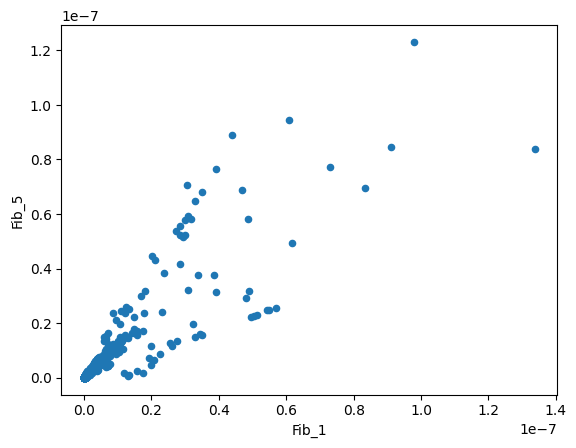

In [288]:
comparison.plot.scatter("Fib_1", "Fib_5")

<Axes: xlabel='Fib_5', ylabel='Fib_4'>

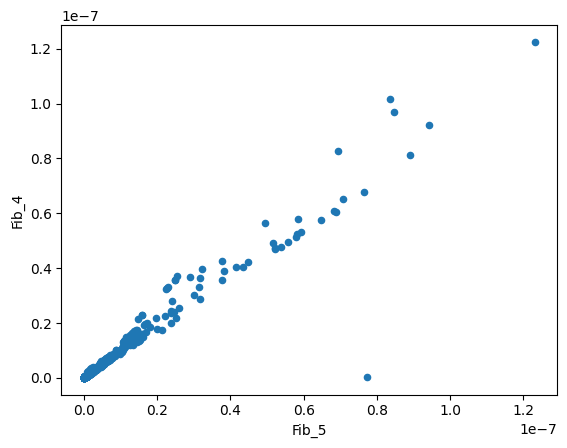

In [289]:
comparison.plot.scatter("Fib_5", "Fib_4")

<Axes: xlabel='Fib_1', ylabel='Fib_4'>

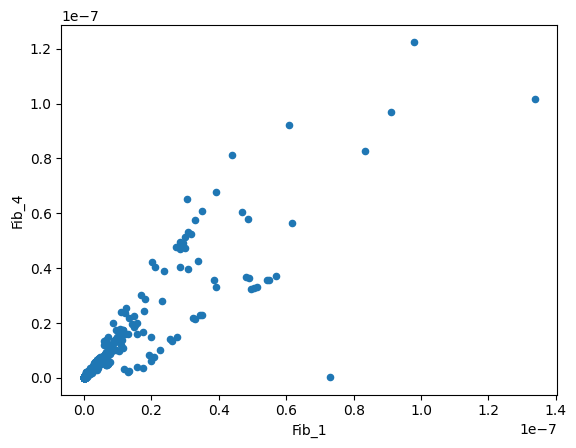

In [290]:
comparison.plot.scatter("Fib_1", "Fib_4")

In [291]:
comparison[["Fib_1", "Fib_4", "Fib_5"]].sort_values(by="Fib_1", ascending=False)[:5]

,Fib_1,Fib_4,Fib_5
gene,,,
CDKN1A,1.337652e-07,1.016012e-07,8.364566e-08
PTGS2,9.792750e-08,1.225560e-07,1.231055e-07
MYC,9.093977e-08,9.710817e-08,8.470682e-08
CCND1,8.339731e-08,8.262127e-08,6.945646e-08
TGFB3,7.295838e-08,1.830708e-10,7.719576e-08


In [292]:
comparison.mean(0)

CM_1       5.160222e-05
Endo_1     9.823654e-06
Fib_1      6.184772e-10
Lymph_1    3.956248e-06
Myelo_1    5.396472e-06
Peri_1     1.090546e-05
vSMCs_1    8.460509e-06
CM_4       5.011717e-06
Endo_4     1.210143e-05
Fib_4      7.258161e-10
Lymph_4    1.519611e-05
Myelo_4    3.009151e-05
Peri_4     9.743675e-06
vSMCs_4    1.761006e-05
CM_5       1.675493e-07
Endo_5     1.087517e-05
Fib_5      7.084476e-10
Lymph_5    1.819055e-05
Myelo_5    3.951561e-05
Peri_5     7.732072e-06
vSMCs_5    1.333433e-05
CM_2       1.847023e-05
Endo_2     1.127030e-05
Fib_2      6.552334e-10
Lymph_2    9.114704e-06
Myelo_2    2.248063e-05
Peri_2     1.225016e-05
vSMCs_2    1.650157e-05
dtype: float64

## Enrichment of the top differentially predicted genes

In [293]:
### from gseapy.parser import read_gmt
import gseapy as gp
from gseapy import Msigdb

msig = Msigdb()
hallmarks = msig.get_gmt(category='h.all', dbver="2024.1.Hs")
# hallmarks = {gene_set:hallmarks[gene_set] for gene_set in hallmarks if 10 < len(hallmarks[gene_set]) < 300}
hallmarks = {k.split("HALLMARK_")[1]:v for k,v in hallmarks.items()}

In [294]:
markers_cell_states = pd.read_csv("../../heart_map/data/cell_states_mrkrs_ttest.csv")

In [311]:
markers_cell_states["group"] = markers_cell_states['group'].str.replace("Myofib", "Myofibroblast")

In [312]:
markers_cm_states = markers_cell_states[markers_cell_states["Unnamed: 0"]=="Fib"]
markers_cm_states

,Unnamed: 0,Unnamed: 1,group,names,scores,logfoldchanges,pvals,pvals_adj,ct
145630,Fib,0,Fib_0,ABCA9,64.512860,1.420706,0.000000e+00,0.000000e+00,Fib
145631,Fib,1,Fib_0,C7,62.743675,1.506750,0.000000e+00,0.000000e+00,Fib
145632,Fib,2,Fib_0,ABCA10,56.255940,1.278064,0.000000e+00,0.000000e+00,Fib
145633,Fib,3,Fib_0,COL4A4,52.418450,1.290226,0.000000e+00,0.000000e+00,Fib
145634,Fib,4,Fib_0,RBMS3,51.609177,0.734035,0.000000e+00,0.000000e+00,Fib
...,...,...,...,...,...,...,...,...,...
262129,Fib,116499,Fib_3,ABI3BP,-32.290070,-1.238069,5.097254e-209,2.474377e-205,Fib
262130,Fib,116500,Fib_3,ITGBL1,-32.583380,-1.828813,2.804286e-217,2.041941e-213,Fib
262131,Fib,116501,Fib_3,COL1A2,-37.440407,-1.444307,1.090687e-272,1.058912e-268,Fib
262132,Fib,116502,Fib_3,COL3A1,-38.432950,-1.589129,1.305066e-286,1.900568e-282,Fib


In [313]:
top_cm_states = markers_cm_states[(markers_cm_states.pvals_adj<0.1) & (markers_cm_states.logfoldchanges>1)]
top_cm_states.group = top_cm_states.group + "_UP"
bottom_cm_states = markers_cm_states[(markers_cm_states.pvals_adj<0.1) & (markers_cm_states.logfoldchanges<-1)]
bottom_cm_states.group = bottom_cm_states.group + "_DOWN"


/local/scratch/tmp/ipykernel_1816080/2509909303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cm_states.group = top_cm_states.group + "_UP"
/local/scratch/tmp/ipykernel_1816080/2509909303.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bottom_cm_states.group = bottom_cm_states.group + "_DOWN"


In [314]:
import pandas as pd

# Assuming your dataframe is called df
# Group by 'group' and collect gene names into lists

# If you just want a dictionary instead of a DataFrame:
group_genes_dict = top_cm_states.groupby("group")["names"].apply(list).to_dict()
#group_genes_dict.update(bottom_cm_states.groupby("group")["names"].apply(list).to_dict())

# Display results
print(group_genes_dict.keys())  # Dictionary mapping group -> list of genes


dict_keys(['Fib_0_UP', 'Fib_3_UP', 'Fib_SCARA5_UP', 'Myofibroblast_UP'])


In [315]:
comparison

,CM_1,Endo_1,Fib_1,Lymph_1,Myelo_1,Peri_1,vSMCs_1,CM_4,Endo_4,Fib_4,...,Myelo_5,Peri_5,vSMCs_5,CM_2,Endo_2,Fib_2,Lymph_2,Myelo_2,Peri_2,vSMCs_2
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,1.426352e-06,2.868521e-07,1.888263e-11,1.146560e-07,1.560813e-07,3.146731e-07,2.431483e-07,1.416217e-07,3.542466e-07,2.239266e-11,...,1.138128e-06,2.250782e-07,3.856581e-07,5.111092e-07,3.247975e-07,1.990013e-11,2.630890e-07,6.452666e-07,3.533954e-07,4.677748e-07
A2M,9.400070e-04,6.434864e-04,6.187079e-10,6.182157e-05,7.241984e-05,4.532750e-04,3.818393e-04,1.015276e-04,8.594701e-04,7.143374e-10,...,4.708465e-04,2.894167e-04,5.445821e-04,3.078382e-04,6.732320e-04,6.567392e-10,1.327023e-04,2.755075e-04,4.672778e-04,6.782695e-04
A4GALT,6.753059e-05,4.910455e-06,7.378464e-11,7.319286e-07,4.224469e-07,4.034855e-06,3.697904e-06,6.726657e-06,6.042695e-06,1.020160e-10,...,3.636042e-06,3.603026e-06,7.377380e-06,3.561764e-05,8.187914e-06,6.228123e-11,2.426297e-06,2.333632e-06,6.645448e-06,1.061064e-05
AAAS,3.204534e-05,2.176536e-06,5.114189e-11,1.239648e-06,1.855069e-06,4.258328e-06,3.328348e-06,3.531470e-06,2.925566e-06,6.282994e-11,...,1.449916e-05,3.258954e-06,5.674451e-06,1.353124e-05,2.823355e-06,5.239488e-11,3.379626e-06,8.984997e-06,5.597260e-06,7.603930e-06
AAGAB,1.154314e-05,2.602267e-06,1.415714e-11,1.417693e-06,1.377889e-06,2.168550e-06,2.336440e-06,1.230725e-06,3.414228e-06,1.617466e-11,...,1.242146e-05,1.913132e-06,4.615404e-06,2.558768e-07,1.517527e-07,1.422231e-11,1.240217e-07,3.019892e-07,1.660978e-07,2.249834e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWILCH,6.076431e-07,1.126405e-07,2.432148e-10,4.607097e-08,6.390775e-08,1.216758e-07,9.444315e-08,5.955518e-08,1.391804e-07,2.175979e-10,...,4.650683e-07,8.695187e-08,1.491911e-07,2.180830e-07,1.305393e-07,1.555219e-10,1.078795e-07,2.676034e-07,1.399145e-07,1.881369e-07
ZYG11B,3.377395e-05,3.624982e-06,1.207403e-10,1.399747e-06,3.096792e-06,4.870288e-06,4.368617e-06,2.720709e-06,3.623963e-06,1.358192e-10,...,2.028653e-05,3.137778e-06,6.277998e-06,8.370616e-06,2.939970e-06,1.345148e-10,2.289625e-06,8.989127e-06,3.872303e-06,5.903605e-06
ZYX,8.134230e-05,2.356336e-05,3.870464e-10,9.692862e-06,4.027356e-05,4.971524e-05,5.737205e-05,6.721228e-06,2.396482e-05,4.983118e-10,...,2.552774e-04,3.098536e-05,7.971233e-05,1.676633e-05,1.532400e-05,4.101164e-10,1.289932e-05,9.307609e-05,3.143677e-05,6.233311e-05


In [316]:
comparison.mean(1)

gene
A1BG      3.680852e-07
A2M       3.661625e-04
A4GALT    7.227678e-06
AAAS      5.509505e-06
AAGAB     2.838831e-06
              ...     
ZWILCH    1.491612e-07
ZYG11B    5.659873e-06
ZYX       4.657209e-05
ZZEF1     7.127982e-06
ZZZ3      8.469976e-07
Length: 10885, dtype: float64

In [317]:
import numpy as np
import pandas as pd
import gseapy as gp

def prerank_contrasts_in_memory(
    comparison_df: pd.DataFrame,
    gene_sets,
    permutations: int = 1000,
    min_size: int = 2,
    max_size: int = 2000,
    epsilon: float = 1e-20,
    seed:int = 1
):
    """
    For each column in `comparison_df` (e.g., Fib_1, Fib_2, Fib_3), compute a signed
    log-ratio contrast vs the mean of the other columns, then run GSEApy prerank
    (in memory) and return a single concatenated results table.

    contrast score (per gene) = log( (target_group + eps) / (mean(other_groups) + eps) )

    Returns
    -------
    rankings_by_contrast : dict[str, pd.Series]
        Mapping from contrast name -> sorted ranking Series (genes -> scores).
    all_enrichments : pd.DataFrame
        Concatenated prerank results with a 'contrast' column.
    """
    # Ensure complete rows for the ranking metric
    comparison_df = comparison_df.dropna(how="any").copy()
    comparison_df /= comparison_df.sum(0)
    group_names = list(comparison_df.columns)
    rankings_by_contrast = {}
    enrichment_tables = []

    for target_group in group_names:
        other_groups = [g for g in group_names if g != target_group]
        mean_of_other_groups = comparison_df[other_groups].mean(axis=1)
        
        # Signed log-ratio (keeps up/down information for prerank)
        contrast_scores = np.log2(
            (comparison_df[target_group]+epsilon) / (mean_of_other_groups+epsilon)+1
        ).sort_values(ascending=False)

        contrast_name = f"{target_group}_vs_mean({','.join(other_groups)})"
        rankings_by_contrast[contrast_name] = contrast_scores

        # Run GSEA in memory (no files written)
        prerank_result = gp.prerank(
            rnk=contrast_scores,           # pandas Series: index=gene, value=score
            gene_sets=gene_sets,           # e.g., your 'hallmarks' object
            outdir=None,                   # keep everything in memory
            permutation_num=permutations,
            min_size=min_size,
            max_size=max_size,
            seed=seed,
            no_plot=True,                  # avoid auto-plotting
            processes=1,                    # adjust if you want parallelism
        )

        # Collect the results table for this contrast
        res_df = prerank_result.res2d.copy()
        res_df["contrast"] = contrast_name
        enrichment_tables.append(res_df)

    all_enrichments = pd.concat(enrichment_tables, ignore_index=True)
    return rankings_by_contrast, all_enrichments


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Inputs ----
# enriched_hallmarks_all: the long DataFrame returned earlier (concatenated res2d) 
# expected columns (varies with gseapy version): 'Term'/'term', 'nes'/'NES', 'fdr'/'FDR q-val'/'pvals_adj', and 'contrast'

def normalize_gseapy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Make column names consistent across gseapy versions."""
    out = df.copy()
    # unify casing
    out.columns = [c.lower() for c in out.columns]
    # rename common variants
    ren = {}
    if 'term' not in out.columns and 'pathway' in out.columns: ren['pathway'] = 'term'
    if 'nes' not in out.columns and 'normalized_enrichment_score' in out.columns: ren['normalized_enrichment_score'] = 'nes'
    # fdr / adjusted p
    for cand in ['fdr', 'fdr q-val', 'fdr_q-val', 'fdr_qval', 'fdrq', 'padj', 'pvals_adj', 'adjusted_p_value']:
        if cand in out.columns:
            ren[cand] = 'fdr'
            break
    out = out.rename(columns=ren)
    required = {'term', 'nes', 'contrast'}
    missing = required - set(out.columns)
    if missing:
        raise ValueError(f"Missing required columns for plotting: {missing}")
    # If FDR not present, create NaNs so plotting code can still run
    if 'fdr' not in out.columns:
        out['fdr'] = np.nan
    return out

def extract_group_from_contrast(contrast: str) -> str:
    """
    Convert 'Fib_1_vs_mean(Fib_4,Fib_5)' -> 'Fib_1'.
    Falls back to the original if the pattern isn't found.
    """
    m = re.match(r'^(.+?)_vs_', contrast)
    return m.group(1) if m else contrast

def build_nes_and_fdr_matrices(enriched_df: pd.DataFrame):
    """Pivot to Term × Group matrices for NES and FDR."""
    df = normalize_gseapy_columns(enriched_df)
    df['group'] = df['contrast'].apply(extract_group_from_contrast)

    # If the same term appears multiple times per group, keep the one with the best (lowest) FDR
    df = (df.sort_values(['group', 'term', 'fdr'], ascending=[True, True, True])
            .drop_duplicates(subset=['group', 'term'], keep='first'))

    nes_mat  = df.pivot(index='term', columns='group', values='nes')
    fdr_mat  = df.pivot(index='term', columns='group', values='fdr')

    # Order pathways by max |NES| across groups (strongest effects first)
    order = np.argsort(-np.nanmax(np.abs(nes_mat.values), axis=1))
    nes_mat = nes_mat.iloc[order].astype(float)
    fdr_mat = fdr_mat.loc[nes_mat.index, nes_mat.columns].astype(float)

    return nes_mat, fdr_mat

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nes_heatmap(nes_mat, fdr_mat, fdr_threshold: float = 0.1,
                     title: str = "Pathway NES per Niche Contrast",
                     figsize=None):
    """
    Plot a seaborn heatmap of NES values (rows=pathways, cols=groups).
    Numbers are bold where FDR < fdr_threshold.
    """
    # Data and color scaling
    data = nes_mat.values
    n_terms, n_groups = data.shape
    vmax = np.nanmax(np.abs(data))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    # Build string labels for annotations (NES with 2 decimals)
    labels = np.empty_like(data, dtype=object)
    for i in range(n_terms):
        for j in range(n_groups):
            val = data[i, j]
            labels[i, j] = "" if np.isnan(val) else f"{val:.2f}"

    # Figure size scales with number of pathways
    if figsize is None:
        fig_h = max(3.5, 0.35 * n_terms + 2)
        fig_w = max(4.8, 1.2 * n_groups + 2)
    else:
        fig_h, fig_w = figsize

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hm = sns.heatmap(
        nes_mat,
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        annot=labels, fmt="",
        cbar_kws={"label": "NES"},
        linewidths=0.2, linecolor="white",
        ax=ax,
    )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(nes_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(nes_mat.index, rotation=0)

    # Bold significant cells & adjust text color for contrast
    # (seaborn stores annotations in ax.texts in row-major order)
    texts = ax.texts
    idx = 0
    for i in range(n_terms):
        for j in range(n_groups):
            if np.isnan(data[i, j]):
                idx += 1
                continue
            # Bold if significant
            fdr_val = np.nan
            if i < fdr_mat.shape[0] and j < fdr_mat.shape[1]:
                fdr_val = fdr_mat.values[i, j]
            if np.isfinite(fdr_val) and (fdr_val < fdr_threshold):
                texts[idx].set_fontweight("bold")

            # White text on strong colors for readability
            if abs(data[i, j]) >= 0.6 * vmax:
                texts[idx].set_color("white")
            else:
                texts[idx].set_color("black")
            idx += 1

    fig.tight_layout()
    return fig, ax
# ------------------- Usage -------------------
# comparison: DataFrame with index=genes, columns like ["Fib_1","Fib_2","Fib_3"]
# hallmarks:  gene sets (e.g., a dict from GSEApy Msigdb/MsigDB GMT, or a string key)


/local/scratch/tmp/ipykernel_1816080/1255421375.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-10-03 12:51:58,036 [WARNING] Duplicated values found in preranked stats: 3.56% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1816080/1255421375.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-10-03 12:52:01,103 [WARNING] Duplicated values found in preranked stats: 3.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1816080/1255421375.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-10-03 12:52:04,170 [WARNING] Duplicated values found in preranked stats: 3.56% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


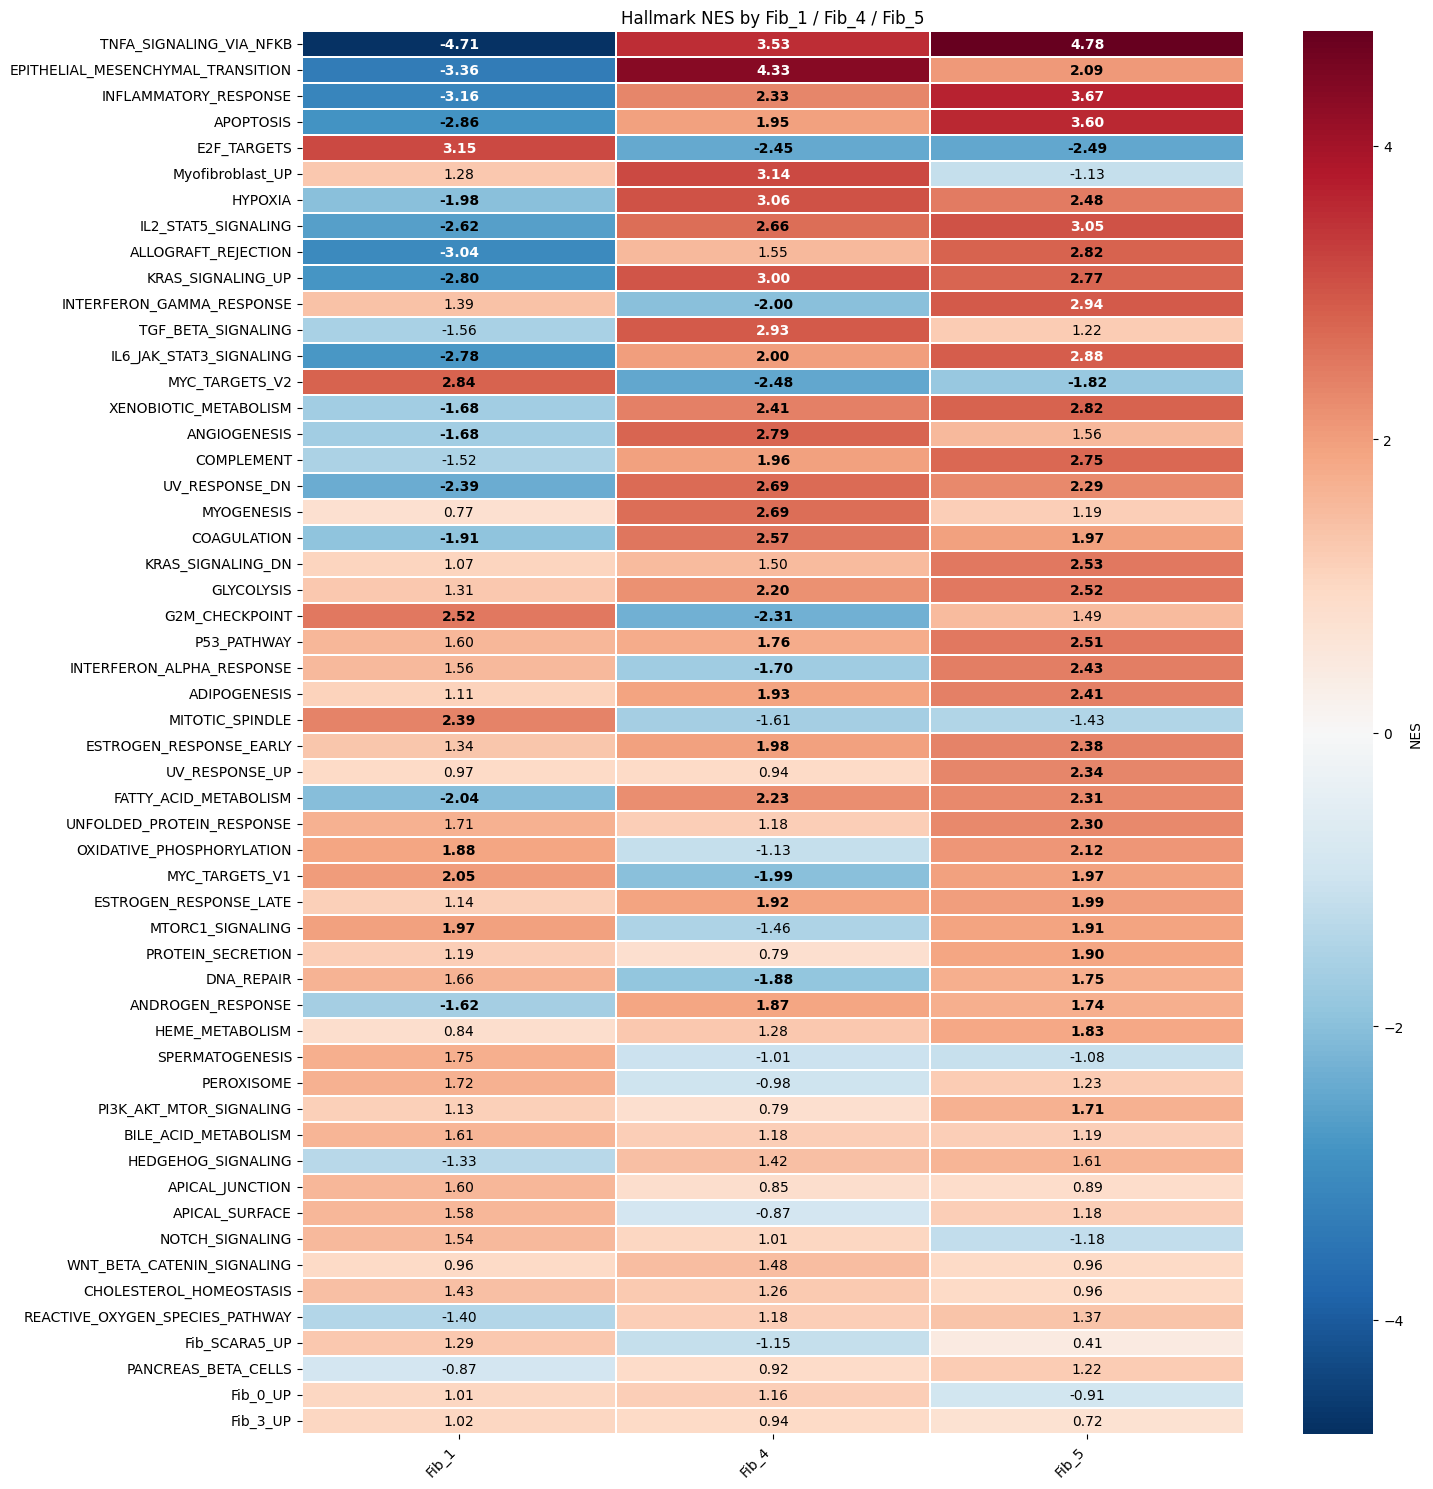

In [318]:

total_genes = {}
total_genes.update(hallmarks)
total_genes.update(group_genes_dict)

rankings_by_contrast, enriched_hallmarks_all = prerank_contrasts_in_memory(
    comparison_df=comparison[["Fib_1", "Fib_4", "Fib_5"]].copy(),
    gene_sets=total_genes,
    permutations=1000,
    min_size=2,
    max_size=2000,
    seed=2025,
)

# ------------------- Run on your results -------------------
# enriched_hallmarks_all is your combined GSEApy table with a 'contrast' column.
nes_matrix, fdr_matrix = build_nes_and_fdr_matrices(enriched_hallmarks_all)

# Plot (all pathways). If this is huge, consider filtering before plotting.
fig, ax = plot_nes_heatmap(nes_matrix, fdr_matrix, fdr_threshold=0.05,
                           title="Hallmark NES by Fib_1 / Fib_4 / Fib_5",
                          figsize=(15,15))

# Optional: filter to pathways significant in any group before plotting:
# mask_sig_any = (fdr_matrix < 0.05).any(axis=1)
# fig, ax = plot_nes_heatmap(nes_matrix[mask_sig_any], fdr_matrix[mask_sig_any])
plt.savefig("enrichment_fib_groups.svg")

In [319]:
def plot_nes_heatmap_horizontal(nes_mat, fdr_mat, fdr_threshold: float = 0.05,
                     title: str = "Pathway NES per Niche Contrast",
                     figsize=None):
    """
    Plot a seaborn heatmap of NES values (rows=pathways, cols=groups).
    Numbers are bold where FDR < fdr_threshold.
    """
    # Data and color scaling
    fdr_mat = fdr_mat.T
    nes_mat = nes_mat.T
    data = nes_mat.values
    n_terms, n_groups = data.shape
    vmax = np.nanmax(np.abs(data))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    # Build string labels for annotations (NES with 2 decimals)
    labels = np.empty_like(data, dtype=object)
    for i in range(n_terms):
        for j in range(n_groups):
            val = data[i, j]
            labels[i, j] = "" if np.isnan(val) else f"{val:.2f}"

    # Figure size scales with number of pathways
    if figsize is None:
        fig_h = max(3.5, 0.35 * n_terms + 2)
        fig_w = max(4.8, 1.2 * n_groups + 2)
    else:
        fig_h, fig_w = figsize

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hm = sns.heatmap(
        nes_mat,
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        annot=labels, fmt="",
        cbar_kws={"label": "NES"},
        linewidths=0.5, linecolor="white",
        ax=ax,
    )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(nes_mat.columns, rotation=90, ha="right")
    ax.set_yticklabels(nes_mat.index, rotation=0)

    # Bold significant cells & adjust text color for contrast
    # (seaborn stores annotations in ax.texts in row-major order)
    texts = ax.texts
    idx = 0
    for i in range(n_terms):
        for j in range(n_groups):
            if np.isnan(data[i, j]):
                idx += 1
                continue
            # Bold if significant
            fdr_val = np.nan
            if i < fdr_mat.shape[0] and j < fdr_mat.shape[1]:
                fdr_val = fdr_mat.values[i, j]
            if np.isfinite(fdr_val) and (fdr_val < fdr_threshold):
                texts[idx].set_fontweight("bold")

            # White text on strong colors for readability
            if abs(data[i, j]) >= 0.6 * vmax:
                texts[idx].set_color("white")
            else:
                texts[idx].set_color("black")
            idx += 1

    fig.tight_layout()
    return fig, ax

In [337]:
fdr_matrix.rename(columns = {
    "Fib_1": "Fibroblast 1 (myogenic)",
    "Fib_4": "Fibroblast 4 (fibrotic)",
    "Fib_5": "Fibroblast 5 (inflammatory)",
                            }, inplace=True)
nes_matrix.rename(columns = {
    "Fib_1": "Fibroblast 1 (myogenic)",
    "Fib_4": "Fibroblast 4 (fibrotic)",
    "Fib_5": "Fibroblast 5 (inflammatory)",
                            }, inplace=True)

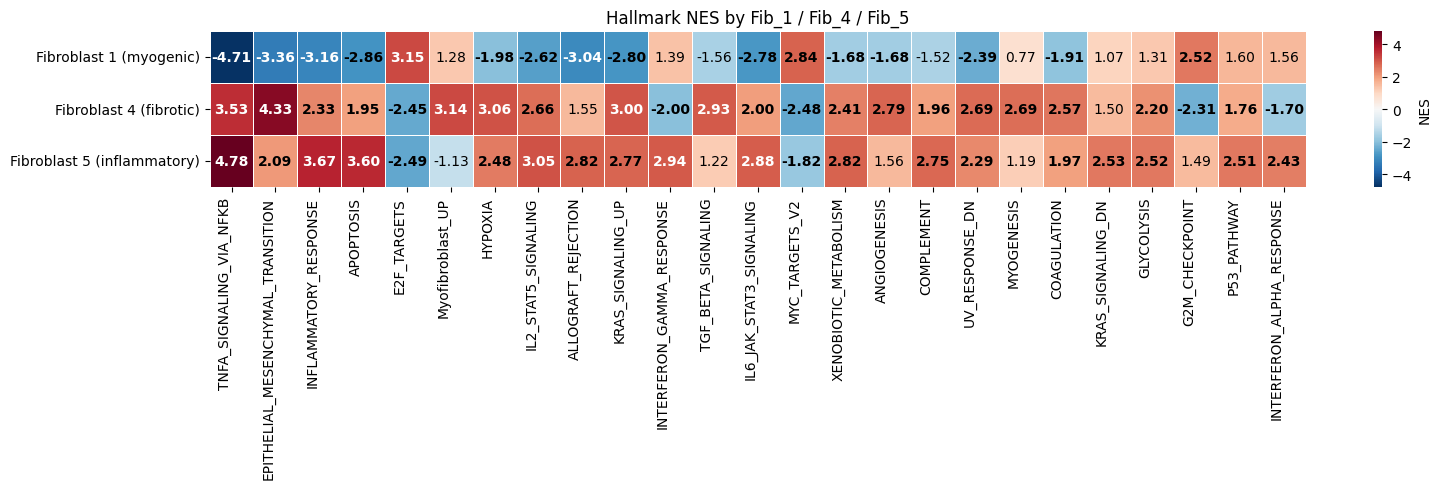

In [362]:
# Plot (all pathways). If this is huge, consider filtering before plotting.
fig, ax = plot_nes_heatmap_horizontal(
    nes_matrix.iloc[:25,],
    fdr_matrix.iloc[:25,],
    fdr_threshold=0.05,
    title="Hallmark NES by Fib_1 / Fib_4 / Fib_5",
    figsize=(5,16))

plt.savefig(f"enrichment_fib_groups{slide}.svg")

/local/scratch/tmp/ipykernel_1407220/139975999.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-30 00:31:06,651 [WARNING] Duplicated values found in preranked stats: 3.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1407220/139975999.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-30 00:31:09,823 [WARNING] Duplicated values found in preranked stats: 3.52% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1407220/139975999.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-30 00:31:12,981 [WARNING] Duplicated values found in preranked stats: 3.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


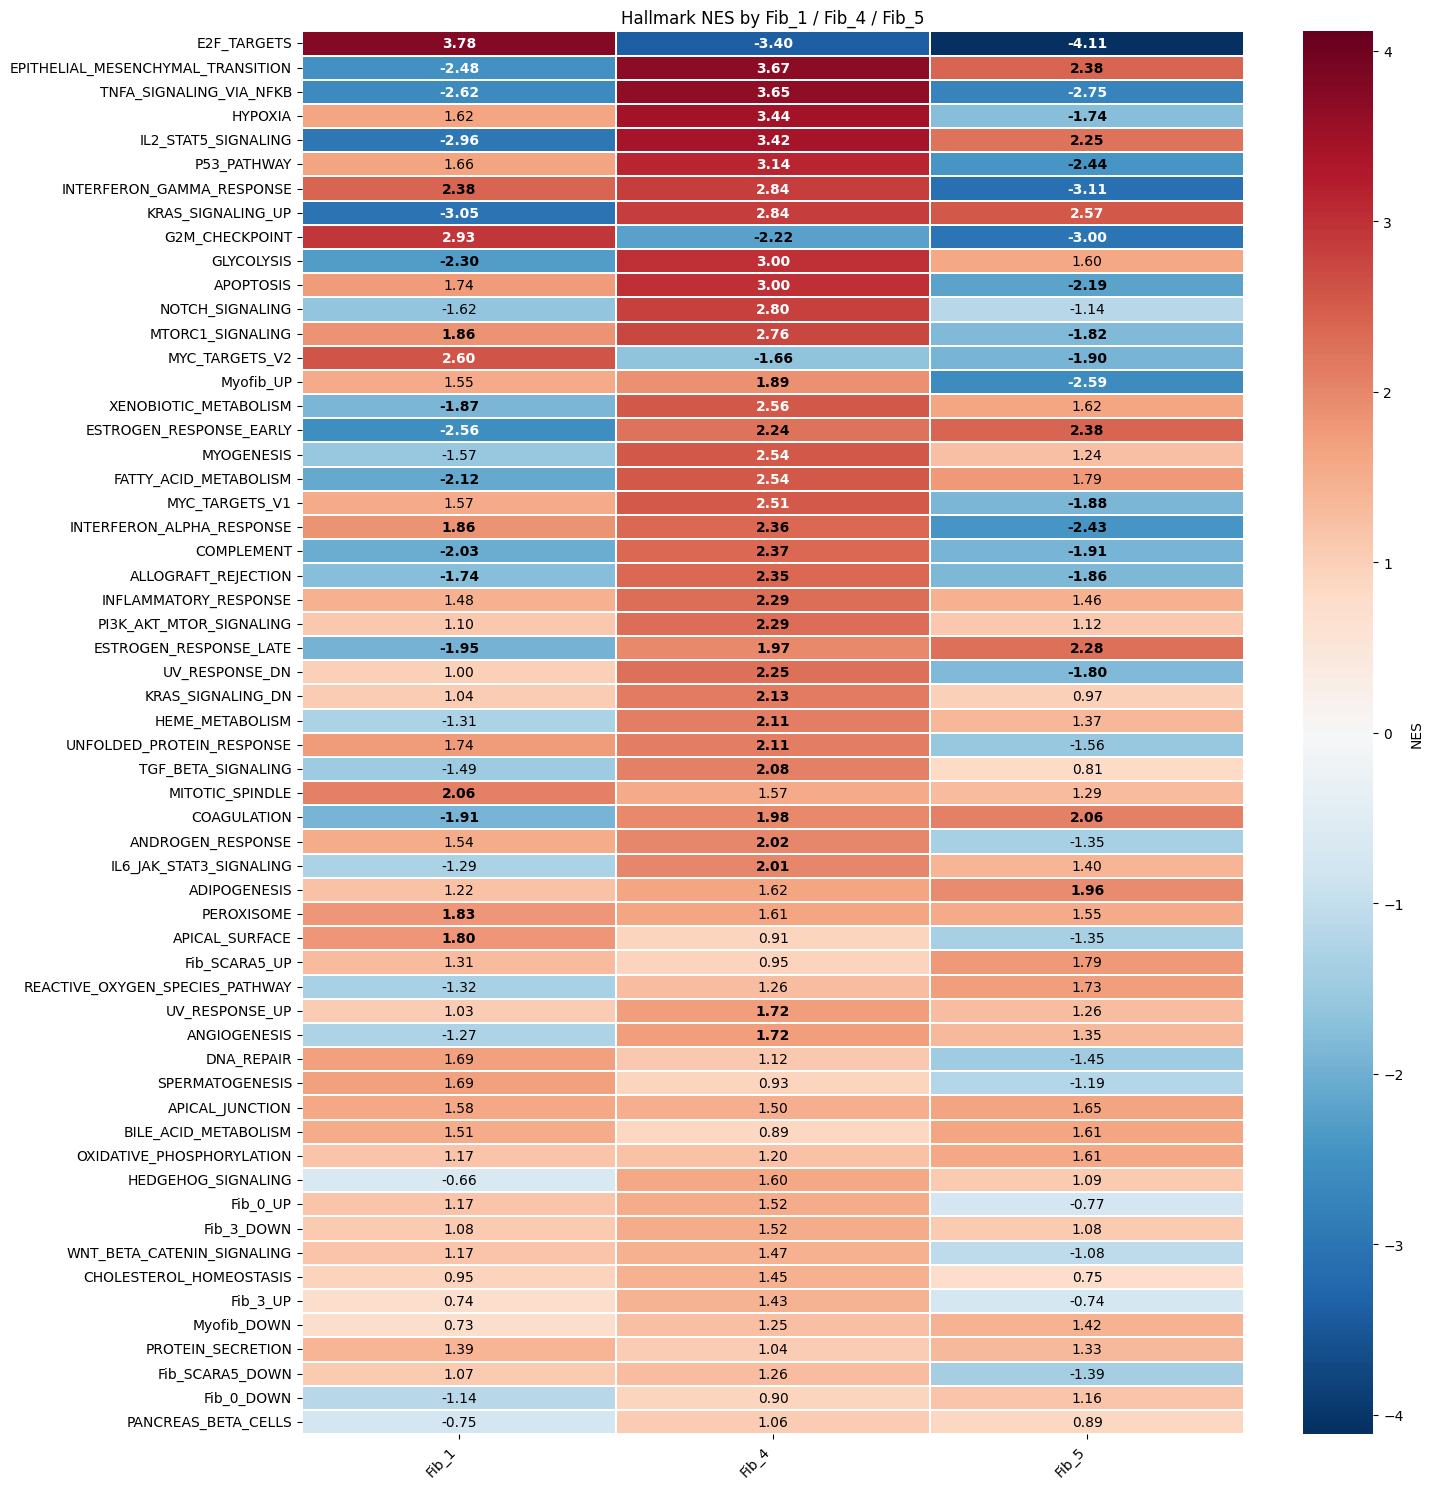

In [484]:
import numpy as np
import pandas as pd
import gseapy as gp

def prerank_contrasts_in_memory(
    comparison_df: pd.DataFrame,
    gene_sets,
    permutations: int = 1000,
    min_size: int = 2,
    max_size: int = 2000,
    epsilon: float = 1e-20,
    seed:int = 1
):
    """
    For each column in `comparison_df` (e.g., Fib_1, Fib_2, Fib_3), compute a signed
    log-ratio contrast vs the mean of the other columns, then run GSEApy prerank
    (in memory) and return a single concatenated results table.

    contrast score (per gene) = log( (target_group + eps) / (mean(other_groups) + eps) )

    Returns
    -------
    rankings_by_contrast : dict[str, pd.Series]
        Mapping from contrast name -> sorted ranking Series (genes -> scores).
    all_enrichments : pd.DataFrame
        Concatenated prerank results with a 'contrast' column.
    """
    # Ensure complete rows for the ranking metric
    comparison_df = comparison_df.dropna(how="any").copy()

    group_names = list(comparison_df.columns)
    rankings_by_contrast = {}
    enrichment_tables = []

    for target_group in group_names:
        other_groups = [g for g in group_names if g != target_group]
        mean_of_other_groups = comparison_df[other_groups].mean(axis=1)

        # Signed log-ratio (keeps up/down information for prerank)
        contrast_scores = (
            (comparison_df[target_group]) / (mean_of_other_groups)
        ).sort_values(ascending=False)

        contrast_name = f"{target_group}_vs_mean({','.join(other_groups)})"
        rankings_by_contrast[contrast_name] = contrast_scores

        # Run GSEA in memory (no files written)
        prerank_result = gp.prerank(
            rnk=contrast_scores,           # pandas Series: index=gene, value=score
            gene_sets=gene_sets,           # e.g., your 'hallmarks' object
            outdir=None,                   # keep everything in memory
            permutation_num=permutations,
            min_size=min_size,
            max_size=max_size,
            seed=seed,
            no_plot=True,                  # avoid auto-plotting
            processes=1,                    # adjust if you want parallelism
        )

        # Collect the results table for this contrast
        res_df = prerank_result.res2d.copy()
        res_df["contrast"] = contrast_name
        enrichment_tables.append(res_df)

    all_enrichments = pd.concat(enrichment_tables, ignore_index=True)
    return rankings_by_contrast, all_enrichments


# ------------------- Usage -------------------
# comparison: DataFrame with index=genes, columns like ["Fib_1","Fib_2","Fib_3"]
# hallmarks:  gene sets (e.g., a dict from GSEApy Msigdb/MsigDB GMT, or a string key)

total_genes = {}
total_genes.update(hallmarks)
total_genes.update(group_genes_dict)

rankings_by_contrast, enriched_hallmarks_all = prerank_contrasts_in_memory(
    comparison_df=comparison[["Fib_1", "Fib_4", "Fib_5"]].copy(),
    gene_sets=total_genes,
    permutations=1000,
    min_size=2,
    max_size=2000,
    seed=10,
)

# Example: inspect the top enrichments for "Fib_1 vs mean(Fib_2,Fib_3)"
enriched_hallmarks_all.query("contrast == 'Fib_1_vs_mean(Fib_4,Fib_5)'") \
    .sort_values("NES", ascending=False) \
    .head(20)


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Inputs ----
# enriched_hallmarks_all: the long DataFrame returned earlier (concatenated res2d) 
# expected columns (varies with gseapy version): 'Term'/'term', 'nes'/'NES', 'fdr'/'FDR q-val'/'pvals_adj', and 'contrast'

def normalize_gseapy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Make column names consistent across gseapy versions."""
    out = df.copy()
    # unify casing
    out.columns = [c.lower() for c in out.columns]
    # rename common variants
    ren = {}
    if 'term' not in out.columns and 'pathway' in out.columns: ren['pathway'] = 'term'
    if 'nes' not in out.columns and 'normalized_enrichment_score' in out.columns: ren['normalized_enrichment_score'] = 'nes'
    # fdr / adjusted p
    for cand in ['fdr', 'fdr q-val', 'fdr_q-val', 'fdr_qval', 'fdrq', 'padj', 'pvals_adj', 'adjusted_p_value']:
        if cand in out.columns:
            ren[cand] = 'fdr'
            break
    out = out.rename(columns=ren)
    required = {'term', 'nes', 'contrast'}
    missing = required - set(out.columns)
    if missing:
        raise ValueError(f"Missing required columns for plotting: {missing}")
    # If FDR not present, create NaNs so plotting code can still run
    if 'fdr' not in out.columns:
        out['fdr'] = np.nan
    return out

def extract_group_from_contrast(contrast: str) -> str:
    """
    Convert 'Fib_1_vs_mean(Fib_4,Fib_5)' -> 'Fib_1'.
    Falls back to the original if the pattern isn't found.
    """
    m = re.match(r'^(.+?)_vs_', contrast)
    return m.group(1) if m else contrast

def build_nes_and_fdr_matrices(enriched_df: pd.DataFrame):
    """Pivot to Term × Group matrices for NES and FDR."""
    df = normalize_gseapy_columns(enriched_df)
    df['group'] = df['contrast'].apply(extract_group_from_contrast)

    # If the same term appears multiple times per group, keep the one with the best (lowest) FDR
    df = (df.sort_values(['group', 'term', 'fdr'], ascending=[True, True, True])
            .drop_duplicates(subset=['group', 'term'], keep='first'))

    nes_mat  = df.pivot(index='term', columns='group', values='nes')
    fdr_mat  = df.pivot(index='term', columns='group', values='fdr')

    # Order pathways by max |NES| across groups (strongest effects first)
    order = np.argsort(-np.nanmax(np.abs(nes_mat.values), axis=1))
    nes_mat = nes_mat.iloc[order].astype(float)
    fdr_mat = fdr_mat.loc[nes_mat.index, nes_mat.columns].astype(float)

    return nes_mat, fdr_mat

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nes_heatmap(nes_mat, fdr_mat, fdr_threshold: float = 0.05,
                     title: str = "Pathway NES per Niche Contrast",
                     figsize=None):
    """
    Plot a seaborn heatmap of NES values (rows=pathways, cols=groups).
    Numbers are bold where FDR < fdr_threshold.
    """
    # Data and color scaling
    data = nes_mat.values
    n_terms, n_groups = data.shape
    vmax = np.nanmax(np.abs(data))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    # Build string labels for annotations (NES with 2 decimals)
    labels = np.empty_like(data, dtype=object)
    for i in range(n_terms):
        for j in range(n_groups):
            val = data[i, j]
            labels[i, j] = "" if np.isnan(val) else f"{val:.2f}"

    # Figure size scales with number of pathways
    if figsize is None:
        fig_h = max(3.5, 0.35 * n_terms + 2)
        fig_w = max(4.8, 1.2 * n_groups + 2)
    else:
        fig_h, fig_w = figsize

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hm = sns.heatmap(
        nes_mat,
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        annot=labels, fmt="",
        cbar_kws={"label": "NES"},
        linewidths=0.2, linecolor="white",
        ax=ax,
    )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(nes_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(nes_mat.index, rotation=0)

    # Bold significant cells & adjust text color for contrast
    # (seaborn stores annotations in ax.texts in row-major order)
    texts = ax.texts
    idx = 0
    for i in range(n_terms):
        for j in range(n_groups):
            if np.isnan(data[i, j]):
                idx += 1
                continue
            # Bold if significant
            fdr_val = np.nan
            if i < fdr_mat.shape[0] and j < fdr_mat.shape[1]:
                fdr_val = fdr_mat.values[i, j]
            if np.isfinite(fdr_val) and (fdr_val < fdr_threshold):
                texts[idx].set_fontweight("bold")

            # White text on strong colors for readability
            if abs(data[i, j]) >= 0.6 * vmax:
                texts[idx].set_color("white")
            else:
                texts[idx].set_color("black")
            idx += 1

    fig.tight_layout()
    return fig, ax


# ------------------- Run on your results -------------------
# enriched_hallmarks_all is your combined GSEApy table with a 'contrast' column.
nes_matrix, fdr_matrix = build_nes_and_fdr_matrices(enriched_hallmarks_all)

# Plot (all pathways). If this is huge, consider filtering before plotting.
fig, ax = plot_nes_heatmap(nes_matrix, fdr_matrix, fdr_threshold=0.05,
                           title="Hallmark NES by Fib_1 / Fib_4 / Fib_5",
                          figsize=(15,15))

# Optional: filter to pathways significant in any group before plotting:
# mask_sig_any = (fdr_matrix < 0.05).any(axis=1)
# fig, ax = plot_nes_heatmap(nes_matrix[mask_sig_any], fdr_matrix[mask_sig_any])
plt.savefig("enrichment_fib_groups.png")

In [154]:
nes_matrix

group,Fib_1,Fib_4,Fib_5
term,,,
EPITHELIAL_MESENCHYMAL_TRANSITION,-2.181179,3.714193,2.837770
P53_PATHWAY,2.682094,-2.167663,-3.533859
Myofib_UP,-2.211984,3.402214,2.389037
Fib_3_DOWN,-1.946717,3.348032,2.369314
E2F_TARGETS,1.593756,3.122739,3.058128
G2M_CHECKPOINT,1.318088,3.098211,2.891139
UV_RESPONSE_DN,1.257645,2.894878,2.155696
ESTROGEN_RESPONSE_EARLY,2.495962,1.202777,-2.881909
TNFA_SIGNALING_VIA_NFKB,1.442095,2.857066,1.559550


/local/scratch/tmp/ipykernel_1407220/1998160883.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-29 22:14:11,970 [WARNING] Duplicated values found in preranked stats: 3.46% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1407220/1998160883.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-29 22:14:15,140 [WARNING] Duplicated values found in preranked stats: 3.52% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/local/scratch/tmp/ipykernel_1407220/1998160883.py:48: DeprecationWarning: processes is deprecated; use threads
  prerank_result = gp.prerank(
2025-09-29 22:14:18,324 [WARNING] Duplicated values found in preranked stats: 3.56% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


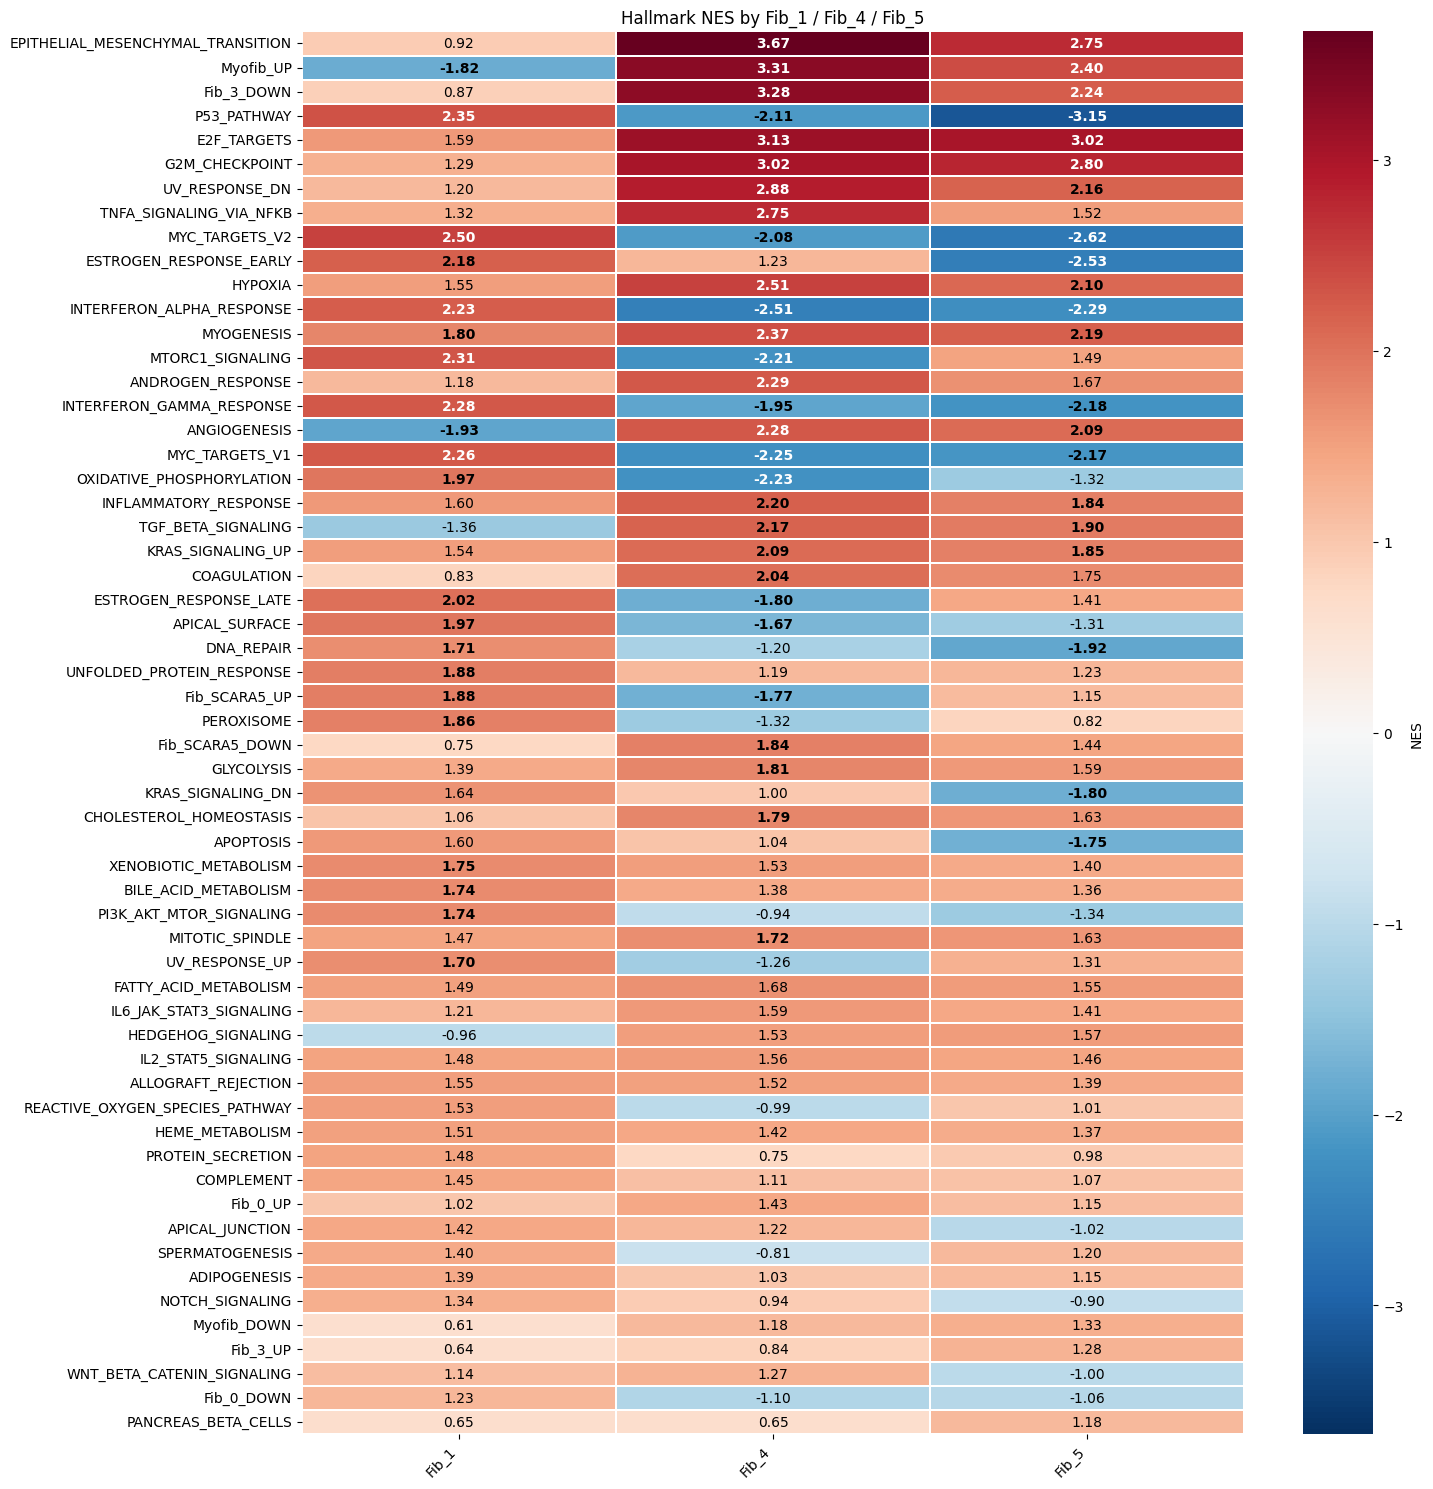

In [160]:
import numpy as np
import pandas as pd
import gseapy as gp

def prerank_contrasts_in_memory(
    comparison_df: pd.DataFrame,
    gene_sets,
    permutations: int = 1000,
    min_size: int = 2,
    max_size: int = 2000,
    seed: int = 10,
    epsilon: float = 1e-20,
):
    """
    For each column in `comparison_df` (e.g., Fib_1, Fib_2, Fib_3), compute a signed
    log-ratio contrast vs the mean of the other columns, then run GSEApy prerank
    (in memory) and return a single concatenated results table.

    contrast score (per gene) = log( (target_group + eps) / (mean(other_groups) + eps) )

    Returns
    -------
    rankings_by_contrast : dict[str, pd.Series]
        Mapping from contrast name -> sorted ranking Series (genes -> scores).
    all_enrichments : pd.DataFrame
        Concatenated prerank results with a 'contrast' column.
    """
    # Ensure complete rows for the ranking metric
    comparison_df = comparison_df.dropna(how="any").copy()

    group_names = list(comparison_df.columns)
    rankings_by_contrast = {}
    enrichment_tables = []

    for target_group in group_names:
        other_groups = [g for g in group_names if g != target_group]
        mean_of_other_groups = comparison_df[other_groups].mean(axis=1)

        # Signed log-ratio (keeps up/down information for prerank)
        contrast_scores = (
            (comparison_df[target_group]) / (mean_of_other_groups)
        ).sort_values(ascending=False)

        contrast_name = f"{target_group}_vs_mean({','.join(other_groups)})"
        rankings_by_contrast[contrast_name] = contrast_scores

        # Run GSEA in memory (no files written)
        prerank_result = gp.prerank(
            rnk=contrast_scores,           # pandas Series: index=gene, value=score
            gene_sets=gene_sets,           # e.g., your 'hallmarks' object
            outdir=None,                   # keep everything in memory
            permutation_num=permutations,
            min_size=min_size,
            max_size=max_size,
            seed=seed,
            no_plot=True,                  # avoid auto-plotting
            processes=1                    # adjust if you want parallelism
        )

        # Collect the results table for this contrast
        res_df = prerank_result.res2d.copy()
        res_df["contrast"] = contrast_name
        enrichment_tables.append(res_df)

    all_enrichments = pd.concat(enrichment_tables, ignore_index=True)
    return rankings_by_contrast, all_enrichments


# ------------------- Usage -------------------
# comparison: DataFrame with index=genes, columns like ["Fib_1","Fib_2","Fib_3"]
# hallmarks:  gene sets (e.g., a dict from GSEApy Msigdb/MsigDB GMT, or a string key)

total_genes = {}
total_genes.update(hallmarks)
total_genes.update(group_genes_dict)

rankings_by_contrast, enriched_hallmarks_all = prerank_contrasts_in_memory(
    comparison_df=comparison[["Fib_1", "Fib_5", "Fib_4"]],
    gene_sets=total_genes,
    permutations=1000,
    min_size=2,
    max_size=2000,
    seed=1,
)

# Example: inspect the top enrichments for "Fib_1 vs mean(Fib_2,Fib_3)"
enriched_hallmarks_all.query("contrast == 'Fib_1_vs_mean(Fib_4,Fib_5)'") \
    .sort_values("NES", ascending=False) \
    .head(20)


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Inputs ----
# enriched_hallmarks_all: the long DataFrame returned earlier (concatenated res2d) 
# expected columns (varies with gseapy version): 'Term'/'term', 'nes'/'NES', 'fdr'/'FDR q-val'/'pvals_adj', and 'contrast'

def normalize_gseapy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Make column names consistent across gseapy versions."""
    out = df.copy()
    # unify casing
    out.columns = [c.lower() for c in out.columns]
    # rename common variants
    ren = {}
    if 'term' not in out.columns and 'pathway' in out.columns: ren['pathway'] = 'term'
    if 'nes' not in out.columns and 'normalized_enrichment_score' in out.columns: ren['normalized_enrichment_score'] = 'nes'
    # fdr / adjusted p
    for cand in ['fdr', 'fdr q-val', 'fdr_q-val', 'fdr_qval', 'fdrq', 'padj', 'pvals_adj', 'adjusted_p_value']:
        if cand in out.columns:
            ren[cand] = 'fdr'
            break
    out = out.rename(columns=ren)
    required = {'term', 'nes', 'contrast'}
    missing = required - set(out.columns)
    if missing:
        raise ValueError(f"Missing required columns for plotting: {missing}")
    # If FDR not present, create NaNs so plotting code can still run
    if 'fdr' not in out.columns:
        out['fdr'] = np.nan
    return out

def extract_group_from_contrast(contrast: str) -> str:
    """
    Convert 'Fib_1_vs_mean(Fib_4,Fib_5)' -> 'Fib_1'.
    Falls back to the original if the pattern isn't found.
    """
    m = re.match(r'^(.+?)_vs_', contrast)
    return m.group(1) if m else contrast

def build_nes_and_fdr_matrices(enriched_df: pd.DataFrame):
    """Pivot to Term × Group matrices for NES and FDR."""
    df = normalize_gseapy_columns(enriched_df)
    df['group'] = df['contrast'].apply(extract_group_from_contrast)

    # If the same term appears multiple times per group, keep the one with the best (lowest) FDR
    df = (df.sort_values(['group', 'term', 'fdr'], ascending=[True, True, True])
            .drop_duplicates(subset=['group', 'term'], keep='first'))

    nes_mat  = df.pivot(index='term', columns='group', values='nes')
    fdr_mat  = df.pivot(index='term', columns='group', values='fdr')

    # Order pathways by max |NES| across groups (strongest effects first)
    order = np.argsort(-np.nanmax(np.abs(nes_mat.values), axis=1))
    nes_mat = nes_mat.iloc[order].astype(float)
    fdr_mat = fdr_mat.loc[nes_mat.index, nes_mat.columns].astype(float)

    return nes_mat, fdr_mat

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nes_heatmap(nes_mat, fdr_mat, fdr_threshold: float = 0.05,
                     title: str = "Pathway NES per Niche Contrast",
                     figsize=None):
    """
    Plot a seaborn heatmap of NES values (rows=pathways, cols=groups).
    Numbers are bold where FDR < fdr_threshold.
    """
    # Data and color scaling
    data = nes_mat.values
    n_terms, n_groups = data.shape
    vmax = np.nanmax(np.abs(data))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    # Build string labels for annotations (NES with 2 decimals)
    labels = np.empty_like(data, dtype=object)
    for i in range(n_terms):
        for j in range(n_groups):
            val = data[i, j]
            labels[i, j] = "" if np.isnan(val) else f"{val:.2f}"

    # Figure size scales with number of pathways
    if figsize is None:
        fig_h = max(3.5, 0.35 * n_terms + 2)
        fig_w = max(4.8, 1.2 * n_groups + 2)
    else:
        fig_h, fig_w = figsize

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    hm = sns.heatmap(
        nes_mat,
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        annot=labels, fmt="",
        cbar_kws={"label": "NES"},
        linewidths=0.2, linecolor="white",
        ax=ax,
    )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(nes_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(nes_mat.index, rotation=0)

    # Bold significant cells & adjust text color for contrast
    # (seaborn stores annotations in ax.texts in row-major order)
    texts = ax.texts
    idx = 0
    for i in range(n_terms):
        for j in range(n_groups):
            if np.isnan(data[i, j]):
                idx += 1
                continue
            # Bold if significant
            fdr_val = np.nan
            if i < fdr_mat.shape[0] and j < fdr_mat.shape[1]:
                fdr_val = fdr_mat.values[i, j]
            if np.isfinite(fdr_val) and (fdr_val < fdr_threshold):
                texts[idx].set_fontweight("bold")

            # White text on strong colors for readability
            if abs(data[i, j]) >= 0.6 * vmax:
                texts[idx].set_color("white")
            else:
                texts[idx].set_color("black")
            idx += 1

    fig.tight_layout()
    return fig, ax


# ------------------- Run on your results -------------------
# enriched_hallmarks_all is your combined GSEApy table with a 'contrast' column.
nes_matrix, fdr_matrix = build_nes_and_fdr_matrices(enriched_hallmarks_all)

# Plot (all pathways). If this is huge, consider filtering before plotting.
fig, ax = plot_nes_heatmap(nes_matrix, fdr_matrix, fdr_threshold=0.05,
                           title="Hallmark NES by Fib_1 / Fib_4 / Fib_5",
                          figsize=(15,15))

# Optional: filter to pathways significant in any group before plotting:
# mask_sig_any = (fdr_matrix < 0.05).any(axis=1)
# fig, ax = plot_nes_heatmap(nes_matrix[mask_sig_any], fdr_matrix[mask_sig_any])
plt.savefig("enrichment_fib_groups.png")

In [156]:
#Fib1 vs Fib2-3
enriched_hallmarks.res2d[:50]

NameError: name 'enriched_hallmarks' is not defined

In [ ]:
top_cm_states

In [366]:
avg_expr_niche_1 = pd.read_csv("../results/cardiomyocyte_subtypes/avg_expression_niche_1_AKK002_157781.csv", index_col=0)
avg_expr_niche_5 = pd.read_csv("../results/cardiomyocyte_subtypes/avg_expression_niche_2_AKK002_157781.csv", index_col=0)
avg_expr_niche_4 = pd.read_csv("../results/cardiomyocyte_subtypes/avg_expression_niche_4_AKK002_157781.csv", index_col=0)

In [367]:
(avg_expr_niche_4.div(avg_expr_niche_4.sum(1), 0)/avg_expr_niche_2.div(avg_expr_niche_2.sum(1), 0)).T["Cardiomyocyte"]

DPM1          1.314440
SCYL3         1.077014
C1orf112      0.477152
FGR           1.226352
CFH           1.798278
                ...   
AL353135.2    1.145918
AC093849.4    0.000000
AC097448.1    1.566575
AC108519.1    0.771234
AL592295.5    1.618369
Name: Cardiomyocyte, Length: 11564, dtype: float64

In [368]:
avg_expr_niche_5

,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,AL513487.1,AC006230.1,AC011407.1,AL953883.1,Z85996.3,AL353135.2,AC093849.4,AC097448.1,AC108519.1,AL592295.5
cell_type,,,,,,,,,,,,,,,,,,,,,
Cardiomyocyte,0.031393,0.004381,0.001823,0.000210,0.001066,0.045899,0.025401,0.004547,0.001706,0.005607,...,0.001387,0.000159,0.000043,0.011129,0.016583,0.002155,0.000034,0.000456,0.000173,0.000549
Endothelial,0.003817,0.000508,0.000260,0.002966,0.005783,0.003797,0.003232,0.000856,0.000458,0.002579,...,0.000007,0.000131,0.001096,0.000030,0.000009,0.000040,0.000012,0.000007,0.000133,0.000040
Fibroblast,0.005775,0.001141,0.000563,0.000218,0.059408,0.007697,0.002691,0.000955,0.000347,0.000968,...,0.000008,0.000147,0.000112,0.000012,0.000008,0.000158,0.000010,0.000026,0.000217,0.000164
Lymphoid,0.002774,0.000718,0.000422,0.002981,0.003834,0.001293,0.002335,0.000596,0.000067,0.002903,...,0.000008,0.000013,0.000033,0.000017,0.000005,0.000018,0.000002,0.000003,0.000051,0.000020
Myeloid,0.004788,0.000751,0.000688,0.025254,0.001001,0.010886,0.007044,0.001345,0.000142,0.000792,...,0.000009,0.000615,0.000003,0.000009,0.000015,0.000020,0.000045,0.000003,0.000075,0.000105
Pericyte,0.003944,0.000624,0.000432,0.000074,0.001401,0.005176,0.002320,0.000913,0.000065,0.000436,...,0.000006,0.000003,0.000580,0.000044,0.000012,0.000191,0.000002,0.000004,0.000169,0.000028
vSMCs,0.005447,0.000896,0.000466,0.000223,0.009666,0.006788,0.001564,0.001124,0.000102,0.000473,...,0.000009,0.000087,0.000844,0.000058,0.000021,0.000116,0.000004,0.000010,0.000237,0.000090


<Axes: xlabel='(pred, Fibroblast)', ylabel='Fibroblast'>

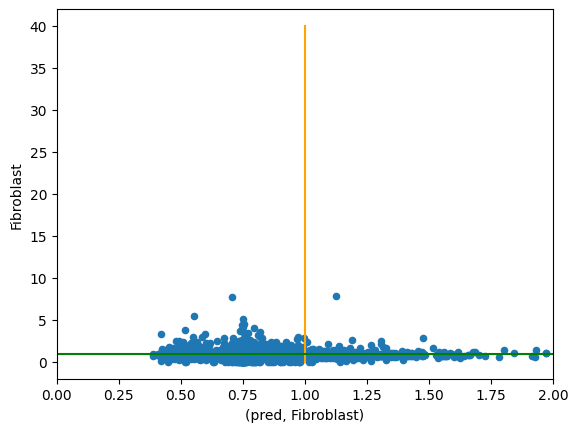

In [369]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1)

ax.set_xlim(0, 2)
plt.plot([1,1], [0,40], color="orange")
plt.plot([0,40], [1,1], color="green")
pd.concat([celltype_pred_niche_1.iloc[:, 2]/celltype_pred_niche_5.iloc[:, 2], (avg_expr_niche_1).T["Fibroblast"]/(avg_expr_niche_5).T["Fibroblast"]], axis=1).plot.scatter(0,"Fibroblast", ax=ax)

In [370]:
celltype_pred_niche_1.loc[:, "Fibroblast"]

KeyError: 'Fibroblast'

In [ ]:
celltype_pred_niche_1.iloc[:, 2]

In [ ]:
top_cm_states.set_index("names").group.unique()

In [ ]:

pd.concat([celltype_pred_niche_1.iloc[:, 2]/celltype_pred_niche_2.iloc[:, 2], bottom_cm_states[bottom_cm_states["group"]=="Myofib_DOWN"].set_index("names")["logfoldchanges"]], axis=1).corr("spearman")

In [372]:
pd.concat([celltype_pred_niche_5.iloc[:, 2]/celltype_pred_niche_1.iloc[:, 2], top_cm_states[top_cm_states["group"]=="Myofib_UP"].set_index("names")["logfoldchanges"]], axis=1).corr("spearman")

,"(pred, Fibroblast)",logfoldchanges
"(pred, Fibroblast)",1.000000,-0.044141
logfoldchanges,-0.044141,1.000000


In [ ]:
pd.concat([celltype_pred_niche_2.iloc[:, 0], avg_expr_niche_2.T.iloc[:, 0]], axis=1).corr("pearson")

In [360]:
pd.concat([celltype_pred_niche_2.iloc[:, 2]/celltype_pred_niche_1.iloc[:, 2], top_cm_states[top_cm_states["group"]=="Myofib_UP"].set_index("names")["logfoldchanges"]], axis=1).plot.scatter(0,1)

NameError: name 'celltype_pred_niche_2' is not defined